In [89]:
import pandas as pd
import numpy as np

In [90]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mobeenfatimah/resume-screening-and-ats-hiring-dataset100k-record/ai_resume_screening_dataset.csv


In [91]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/resume-screening-and-ats-hiring-dataset100k-record/ai_resume_screening_dataset.csv')

# Display the first 5 rows
df.head()

KeyboardInterrupt: 

In [92]:
# Check number of rows and columns
print("Dataset shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

# Check data types and missing values
df.info()

Dataset shape: (100000, 44)

Columns:
['candidate_id', 'full_name', 'email', 'phone', 'country', 'city', 'age', 'gender', 'highest_education', 'university', 'field_of_study', 'cgpa', 'graduation_year', 'experience_years', 'previous_companies', 'current_job_title', 'internship_experience', 'leadership_experience', 'technical_skills', 'programming_languages', 'frameworks', 'databases', 'cloud_platform', 'projects_completed', 'github_profile', 'linkedin_profile', 'certifications', 'publications', 'communication_score', 'problem_solving_score', 'technical_test_score', 'interview_score', 'aptitude_score', 'job_role', 'expected_salary', 'preferred_location', 'employment_type', 'remote_preference', 'availability', 'resume_quality_score', 'resume_length', 'keyword_match_percentage', 'ats_score', 'selected']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------            

### Dataset Overview

The dataset contains **100,000 candidate records and 44 features** related to recruitment and Applicant Tracking System (ATS) screening.

The variables cover several aspects of the recruitment process, including:

* **Candidate information:** age, gender, country, city
* **Education:** highest education, university, field of study, and CGPA
* **Professional experience:** experience years, previous companies, current job title, internships, and leadership experience
* **Technical background:** technical skills, programming languages, frameworks, databases, and cloud platforms
* **Performance scores:** communication, problem-solving, technical test, interview, and aptitude scores
* **Job preferences:** job role, expected salary, preferred location, employment type, remote preference, and availability
* **Resume/ATS metrics:** resume quality score, resume length, keyword match percentage, and ATS score
* **Target variable:** `selected`, which indicates whether a candidate was selected or rejected.

The dataset contains **28 categorical variables, 14 integer variables, and 2 numerical variables (float)**. There are **no missing values**, as all 100,000 records have non-null values across the 44 columns.


In [93]:
# Check for missing values
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [94]:
# Check for duplicate records
duplicates = df.duplicated().sum()

print("Total duplicate records:", duplicates)

Total duplicate records: 0


In [98]:
# Check the distribution of the target variable
print(df['selected'].value_counts())

selected
Selected    50000
Rejected    50000
Name: count, dtype: int64


In [99]:
# Check the percentage distribution
print(df['selected'].value_counts(normalize=True) * 100)

selected
Selected    50.0
Rejected    50.0
Name: proportion, dtype: float64


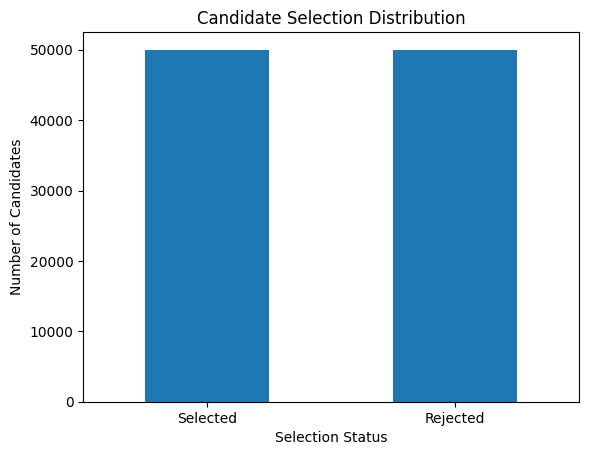

In [100]:
import matplotlib.pyplot as plt

# Count selected and rejected candidates
selection_counts = df['selected'].value_counts()

# Plot the distribution
selection_counts.plot(kind='bar')

plt.title('Candidate Selection Distribution')
plt.xlabel('Selection Status')
plt.ylabel('Number of Candidates')
plt.xticks(rotation=0)
plt.show()

**Descriptive Statistics**

In [101]:
# Generate descriptive statistics for numerical variables
df.describe()

,age,cgpa,graduation_year,experience_years,projects_completed,publications,communication_score,problem_solving_score,technical_test_score,interview_score,aptitude_score,expected_salary,resume_quality_score,resume_length,keyword_match_percentage,ats_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,37.992810,3.248341,2008.946510,16.055770,6.49118,0.379640,69.434840,71.413430,67.329030,69.370380,70.386160,177185.890000,74.533620,2.503400,28.092025,51.23903
std,10.095701,0.433409,10.134017,10.101397,3.45233,0.744781,14.655934,13.733492,15.718161,14.655315,12.787774,66542.036588,11.601866,1.117274,12.521891,8.58256
min,21.000000,2.500000,1989.000000,0.000000,1.00000,0.000000,30.000000,30.000000,25.000000,30.000000,35.000000,45000.000000,50.000000,1.000000,20.000000,40.00000
25%,29.000000,2.870000,2000.000000,7.000000,3.00000,0.000000,59.000000,62.000000,57.000000,59.000000,62.000000,122000.000000,66.000000,2.000000,20.000000,45.00000
50%,38.000000,3.250000,2009.000000,16.000000,6.00000,0.000000,69.000000,72.000000,67.000000,69.000000,70.000000,175000.000000,75.000000,3.000000,20.000000,50.00000
75%,47.000000,3.620000,2018.000000,25.000000,9.00000,0.000000,80.000000,81.000000,78.000000,80.000000,79.000000,229000.000000,83.000000,3.000000,32.820000,56.00000
max,55.000000,4.000000,2026.000000,35.000000,12.00000,3.000000,100.000000,100.000000,100.000000,100.000000,100.000000,401000.000000,100.000000,4.000000,100.000000,99.00000


The descriptive statistics show that the dataset contains a wide range of candidate characteristics and recruitment-related scores. The average candidate age is approximately 38 years, while the average CGPA is 3.25. Candidates have an average of approximately 16 years of professional experience and have completed about 6 projects.

The average communication, problem-solving, technical test, interview, and aptitude scores are generally between 67 and 71 out of 100. The average resume quality score is approximately 74.5, while the average ATS score is approximately 51.2.

The keyword match percentage has a relatively low average of approximately 28.1%, indicating that many resumes have relatively low keyword matching scores. Expected salary has an average of approximately 177,186.

These statistics provide an initial understanding of the numerical variables. Further exploratory analysis will be conducted to examine their distributions, relationships, and potential outliers.

**categorical variables**

In [102]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Number of unique values in each categorical column
df[categorical_columns].nunique().sort_values(ascending=False)

candidate_id             100000
phone                    100000
linkedin_profile          99894
email                     99727
github_profile            99188
technical_skills          97372
full_name                 71126
city                      37950
previous_companies        34104
preferred_location        15831
frameworks                 8998
certifications              821
country                     243
programming_languages       235
databases                   234
cloud_platform              230
current_job_title            16
job_role                     15
university                   15
field_of_study                9
availability                  5
highest_education             5
employment_type               4
gender                        3
remote_preference             3
internship_experience         2
leadership_experience         2
selected                      2
dtype: int64

The dataset contains 28 categorical variables with different numbers of unique values. Some variables have very high cardinality, such as candidate_id, phone, email, linkedin_profile, and github_profile. These variables primarily serve as identifiers or contact information and do not provide useful predictive information for determining candidate selection.

Other variables, such as highest_education, employment_type, remote_preference, internship_experience, and leadership_experience, contain a relatively small number of categories and can be considered as potential predictive features.

Variables with very high cardinality will therefore require careful handling during preprocessing, while direct identifiers and personal contact information will be excluded from the machine learning features.

In [103]:
# Display the unique values for selected categorical variables

categorical_features = [
    'gender',
    'highest_education',
    'field_of_study',
    'internship_experience',
    'leadership_experience',
    'employment_type',
    'remote_preference',
    'availability',
    'job_role'
]

for column in categorical_features:
    print(f"\n{column}:")
    print(df[column].value_counts())


gender:
gender
Male      49112
Female    48954
Other      1934
Name: count, dtype: int64

highest_education:
highest_education
Bachelor       54807
Master         25285
Diploma        10018
High School     5001
PhD             4889
Name: count, dtype: int64

field_of_study:
field_of_study
Cyber Security              11321
Information Technology      11228
Mathematics & Statistics    11215
Information Systems         11120
Software Engineering        11107
Electrical Engineering      11086
Artificial Intelligence     11082
Data Science                10996
Computer Science            10845
Name: count, dtype: int64

internship_experience:
internship_experience
No     55179
Yes    44821
Name: count, dtype: int64

leadership_experience:
leadership_experience
No     55763
Yes    44237
Name: count, dtype: int64

employment_type:
employment_type
Full-Time     25070
Part-Time     25048
Contract      24970
Internship    24912
Name: count, dtype: int64

remote_preference:
remote_preference
On-

In [104]:
# Selection outcome by education level
education_selection = pd.crosstab(
    df['highest_education'],
    df['selected'],
    normalize='index'
) * 100

education_selection

selected,Rejected,Selected
highest_education,,
Bachelor,50.050176,49.949824
Diploma,49.251348,50.748652
High School,49.510098,50.489902
Master,50.535891,49.464109
PhD,48.701166,51.298834


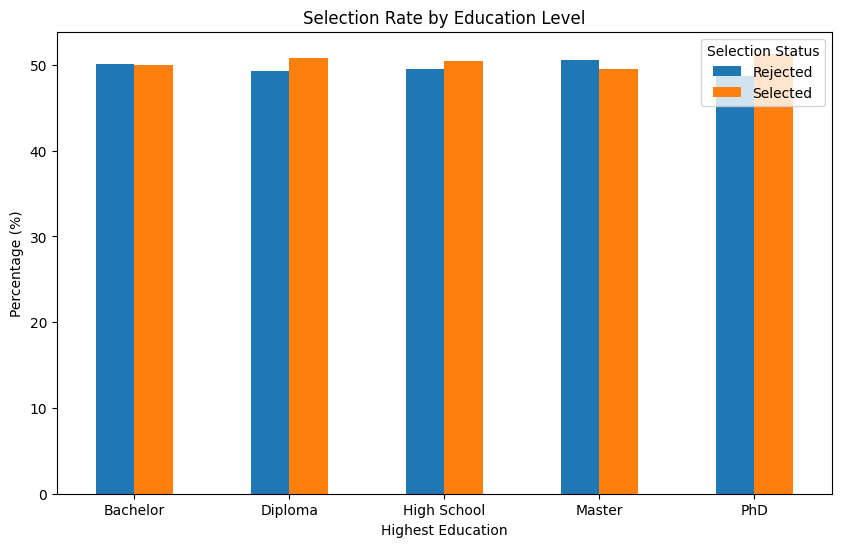

In [105]:
# Visualize selection rate by education level
education_selection.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Selection Rate by Education Level')
plt.xlabel('Highest Education')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Selection Status')
plt.show()

In [106]:
# Selection rate by experience level
experience_selection = pd.crosstab(
    df['experience_years'],
    df['selected'],
    normalize='index'
) * 100

experience_selection

selected,Rejected,Selected
experience_years,,
0,99.894570,0.105430
1,99.550795,0.449205
2,99.356913,0.643087
3,98.954469,1.045531
4,97.065140,2.934860
5,95.147376,4.852624
6,92.421125,7.578875
7,89.217759,10.782241
8,84.425933,15.574067


In [ ]:
# Plot selection rate by years of experience
experience_selection.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Selection Rate by Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Selection Status')
plt.show()

In [ ]:
# Check the relationship between age and experience
df[['age', 'experience_years']].corr()

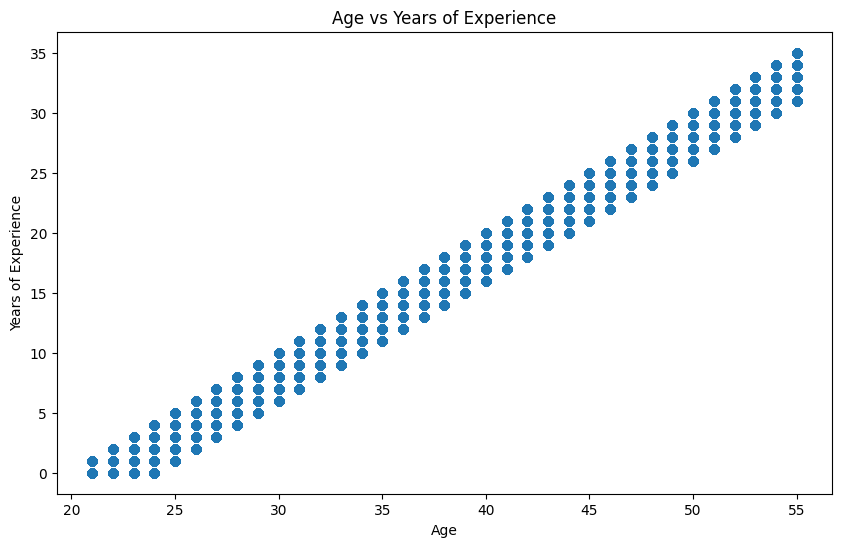

In [107]:
# Visualize age versus years of experience
plt.figure(figsize=(10, 6))

plt.scatter(
    df['age'],
    df['experience_years'],
    alpha=0.3
)

plt.title('Age vs Years of Experience')
plt.xlabel('Age')
plt.ylabel('Years of Experience')
plt.show()

In [108]:
# Compare ATS scores between selected and rejected candidates

ats_selection = df.groupby('selected')['ats_score'].agg(
    ['mean', 'median', 'min', 'max']
)

ats_selection

,mean,median,min,max
selected,,,,
Rejected,49.83446,49.0,40,94
Selected,52.64360,52.0,40,99


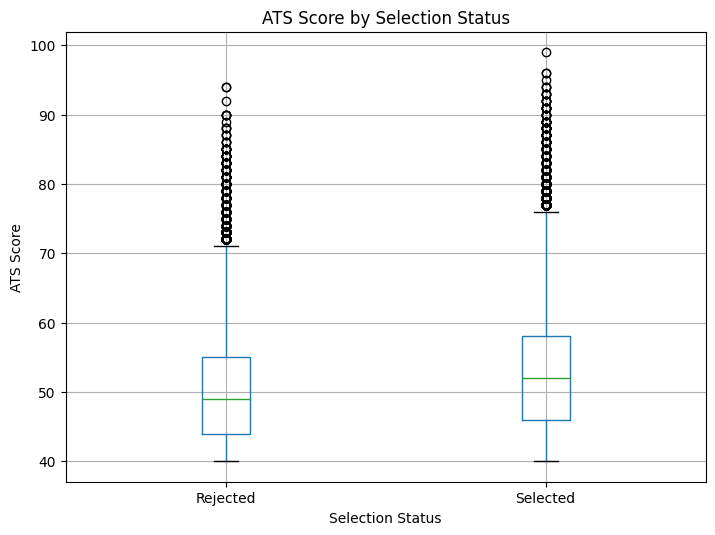

In [109]:
# Visualize ATS score by selection status

df.boxplot(
    column='ats_score',
    by='selected',
    figsize=(8, 6)
)

plt.title('ATS Score by Selection Status')
plt.suptitle('')
plt.xlabel('Selection Status')
plt.ylabel('ATS Score')

plt.show()

In [110]:
# Compare keyword match percentage between selected and rejected candidates

df.groupby('selected')['keyword_match_percentage'].agg(
    ['mean', 'median', 'min', 'max']
)

,mean,median,min,max
selected,,,,
Rejected,26.133792,20.00,20.0,98.78
Selected,30.050258,22.32,20.0,100.00


<Figure size 1000x600 with 0 Axes>

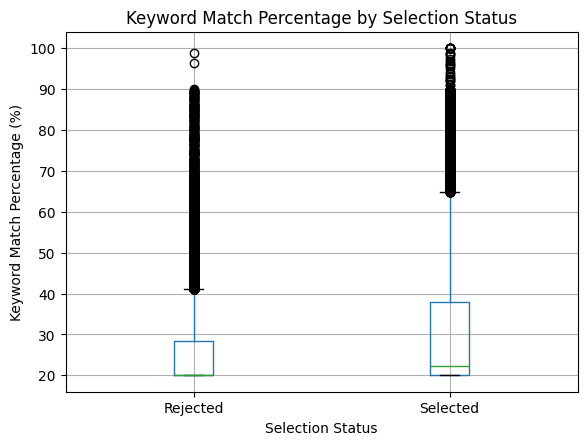

In [111]:
# Visualize keyword match percentage by selection status

plt.figure(figsize=(10, 6))

df.boxplot(
    column='keyword_match_percentage',
    by='selected'
)

plt.title('Keyword Match Percentage by Selection Status')
plt.suptitle('')
plt.xlabel('Selection Status')
plt.ylabel('Keyword Match Percentage (%)')

plt.show()

In [112]:
# Compare resume quality scores between selected and rejected candidates

df.groupby('selected')['resume_quality_score'].agg(
    ['mean', 'median', 'min', 'max']
)

,mean,median,min,max
selected,,,,
Rejected,73.76598,74.0,50,100
Selected,75.30126,75.0,50,100


<Figure size 1000x600 with 0 Axes>

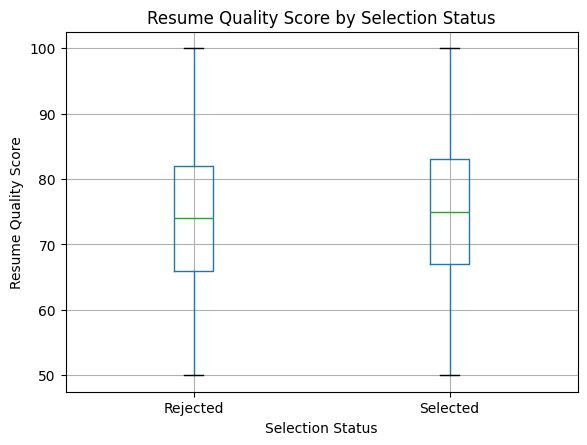

In [113]:
# Visualize resume quality score by selection status

plt.figure(figsize=(10, 6))

df.boxplot(
    column='resume_quality_score',
    by='selected'
)

plt.title('Resume Quality Score by Selection Status')
plt.suptitle('')
plt.xlabel('Selection Status')
plt.ylabel('Resume Quality Score')

plt.show()

In [114]:
# Compare average performance scores by selection status

performance_columns = [
    'communication_score',
    'problem_solving_score',
    'technical_test_score',
    'interview_score',
    'aptitude_score'
]

df.groupby('selected')[performance_columns].mean()

,communication_score,problem_solving_score,technical_test_score,interview_score,aptitude_score
selected,,,,,
Rejected,68.64782,70.02972,64.61420,66.94468,69.83898
Selected,70.22186,72.79714,70.04386,71.79608,70.93334


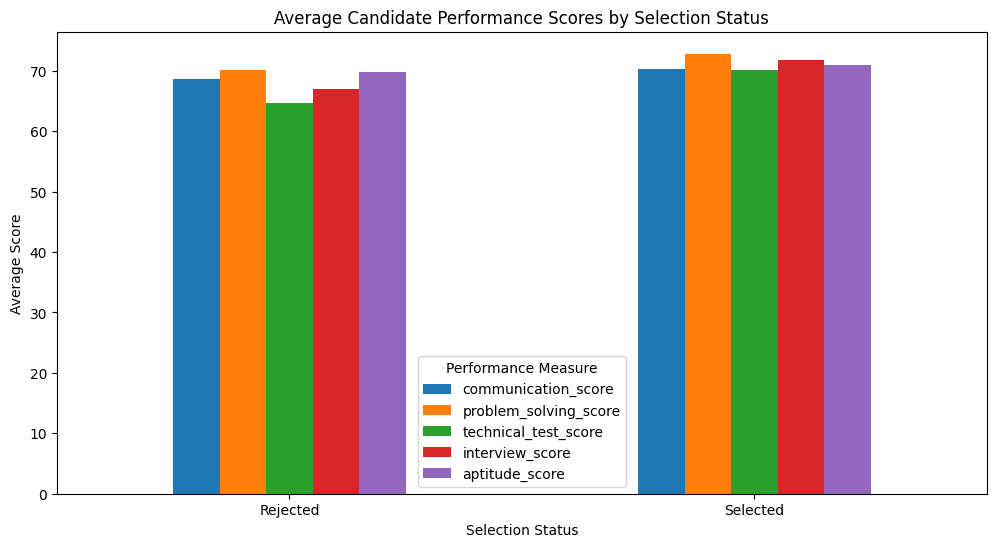

In [115]:
# Visualize average performance scores by selection status

performance_means = df.groupby('selected')[performance_columns].mean()

performance_means.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Candidate Performance Scores by Selection Status')
plt.xlabel('Selection Status')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Performance Measure')
plt.show()

In [116]:
# Compare ATS-related metrics by selection status

ats_features = [
    'ats_score',
    'keyword_match_percentage',
    'resume_quality_score'
]

df.groupby('selected')[ats_features].mean()

,ats_score,keyword_match_percentage,resume_quality_score
selected,,,
Rejected,49.83446,26.133792,73.76598
Selected,52.64360,30.050258,75.30126


In [117]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate correlation matrix
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,age,cgpa,graduation_year,experience_years,projects_completed,publications,communication_score,problem_solving_score,technical_test_score,interview_score,aptitude_score,expected_salary,resume_quality_score,resume_length,keyword_match_percentage,ats_score
age,1.000000,0.000518,-0.987246,0.990497,-0.002683,0.004435,-0.002123,0.001928,0.000266,0.002073,-0.005406,0.933381,-0.003668,0.003942,-0.003973,-0.004850
cgpa,0.000518,1.000000,-0.000170,0.000110,0.000791,0.005681,0.006647,-0.001233,0.000926,-0.003723,-0.001125,0.001157,0.005575,0.002976,0.001639,0.004713
graduation_year,-0.987246,-0.000170,1.000000,-0.996753,0.002793,-0.003928,0.002550,-0.001729,-0.000406,-0.002323,0.004963,-0.939501,0.003272,-0.003872,0.003991,0.004447
experience_years,0.990497,0.000110,-0.996753,1.000000,-0.003034,0.004385,-0.002828,0.001637,0.000252,0.002191,-0.004936,0.942525,-0.003340,0.003686,-0.003799,-0.004419
projects_completed,-0.002683,0.000791,0.002793,-0.003034,1.000000,-0.002490,-0.003148,-0.001105,-0.001824,-0.001608,0.003711,-0.001665,0.003038,0.002883,0.001377,0.001220
publications,0.004435,0.005681,-0.003928,0.004385,-0.002490,1.000000,0.001505,0.000200,0.000730,0.001334,-0.000786,0.005491,-0.002369,0.000924,0.000725,-0.000730
communication_score,-0.002123,0.006647,0.002550,-0.002828,-0.003148,0.001505,1.000000,-0.002349,0.000197,0.000149,0.000392,-0.000132,0.001336,-0.000674,0.002438,0.002462
problem_solving_score,0.001928,-0.001233,-0.001729,0.001637,-0.001105,0.000200,-0.002349,1.000000,0.000003,-0.002219,-0.002067,0.002477,0.001104,-0.003818,0.006004,0.004440
technical_test_score,0.000266,0.000926,-0.000406,0.000252,-0.001824,0.000730,0.000197,0.000003,1.000000,0.000171,-0.002628,-0.000049,0.000870,0.002314,0.003068,0.002095
interview_score,0.002073,-0.003723,-0.002323,0.002191,-0.001608,0.001334,0.000149,-0.002219,0.000171,1.000000,0.001658,-0.000213,0.001127,0.002999,-0.001462,-0.000864


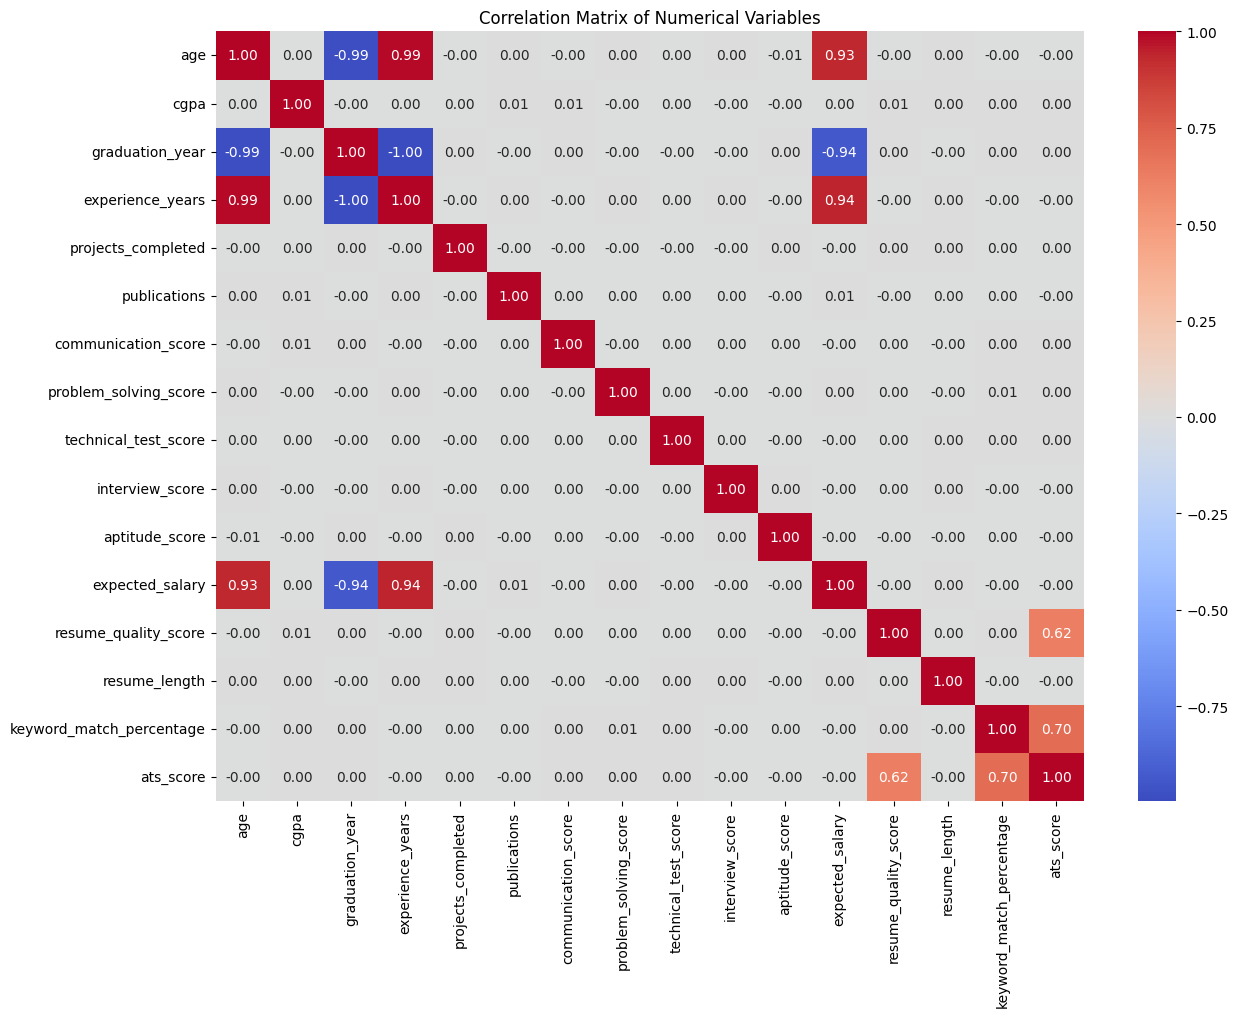

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [119]:
# Convert selection status to binary
df['selected_binary'] = df['selected'].map({
    'Rejected': 0,
    'Selected': 1
})

# Calculate correlations with selection
selection_correlations = df[numerical_columns].corrwith(
    df['selected_binary']
).sort_values(ascending=False)

selection_correlations

experience_years            0.569163
age                         0.565791
expected_salary             0.535356
technical_test_score        0.172720
interview_score             0.165518
ats_score                   0.163655
keyword_match_percentage    0.156386
cgpa                        0.136303
problem_solving_score       0.100755
resume_quality_score        0.066166
communication_score         0.053700
aptitude_score              0.042790
projects_completed          0.004188
publications                0.002121
resume_length               0.001736
graduation_year            -0.567200
dtype: float64

In [120]:
# Calculate selection rate by job role

job_role_selection = pd.crosstab(
    df['job_role'],
    df['selected'],
    normalize='index'
) * 100

# Sort by selected rate
job_role_selection = job_role_selection.sort_values(
    'Selected',
    ascending=False
)

job_role_selection

selected,Rejected,Selected
job_role,,
Business Analyst,48.859741,51.140259
QA Engineer,49.006623,50.993377
Machine Learning Engineer,49.089024,50.910976
Frontend Developer,49.628226,50.371774
Software Engineer,49.689347,50.310653
Backend Developer,49.840692,50.159308
AI Engineer,49.887842,50.112158
Full Stack Developer,49.954941,50.045059
Cyber Security Analyst,49.992489,50.007511


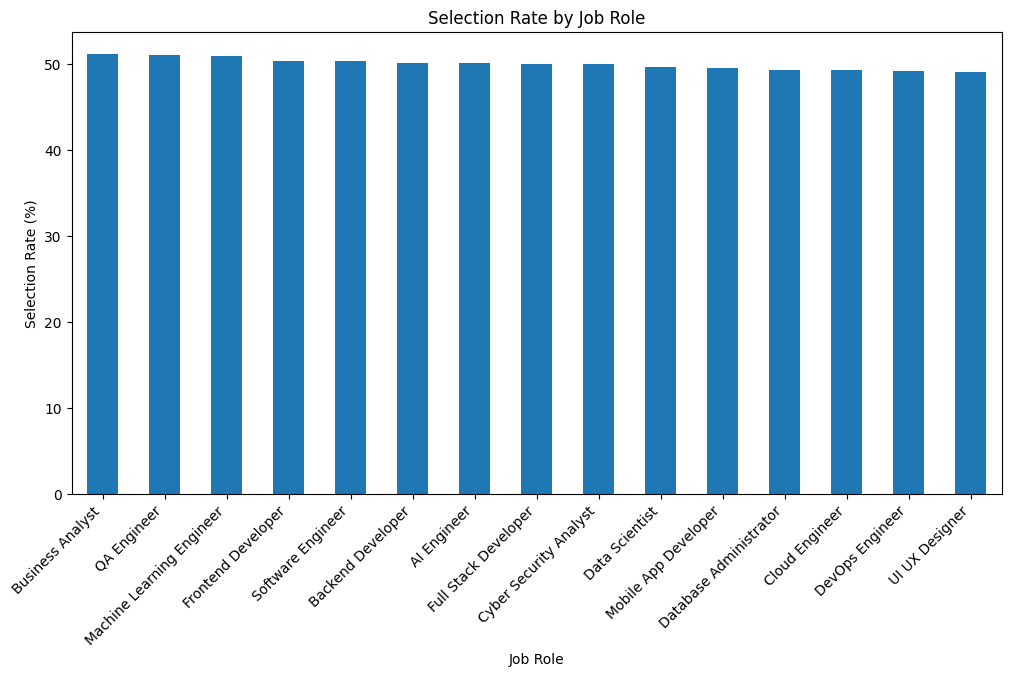

In [121]:
# Visualize selection rate by job role

job_role_selection['Selected'].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Selection Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Selection Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [122]:
# Selection rate by employment type

employment_selection = pd.crosstab(
    df['employment_type'],
    df['selected'],
    normalize='index'
) * 100

employment_selection

selected,Rejected,Selected
employment_type,,
Contract,49.943933,50.056067
Full-Time,49.948145,50.051855
Internship,50.020071,49.979929
Part-Time,50.087831,49.912169


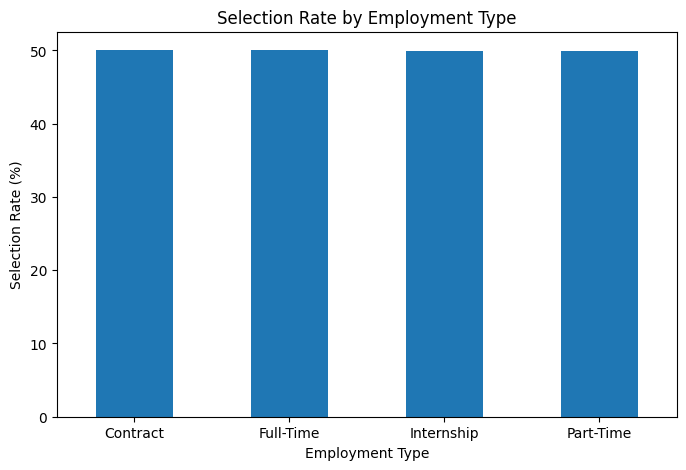

In [123]:
# Visualize selection rate by employment type

employment_selection['Selected'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Selection Rate by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Selection Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [124]:
# Selection rate by remote preference

remote_selection = pd.crosstab(
    df['remote_preference'],
    df['selected'],
    normalize='index'
) * 100

remote_selection

selected,Rejected,Selected
remote_preference,,
Hybrid,50.188906,49.811094
On-site,49.994006,50.005994
Remote,49.816729,50.183271


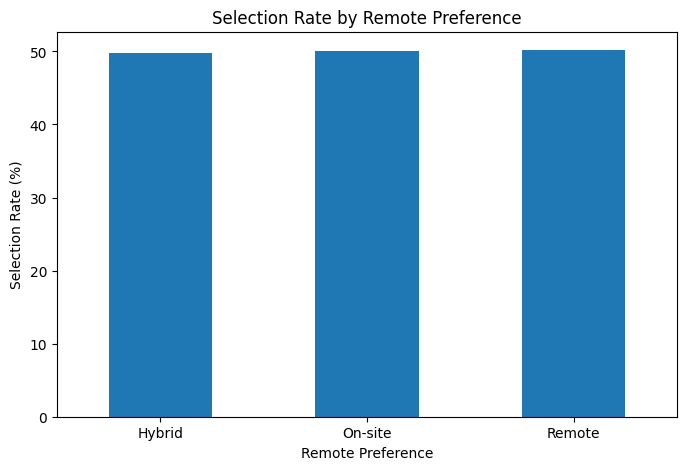

In [125]:
# Visualize selection rate by remote preference

remote_selection['Selected'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Selection Rate by Remote Preference')
plt.xlabel('Remote Preference')
plt.ylabel('Selection Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [126]:
# Selection rate by internship experience

internship_selection = pd.crosstab(
    df['internship_experience'],
    df['selected'],
    normalize='index'
) * 100

internship_selection

selected,Rejected,Selected
internship_experience,,
No,45.906957,54.093043
Yes,55.038933,44.961067


In [127]:
# Selection rate by leadership experience


leadership_selection = pd.crosstab(
    df['leadership_experience'],
    df['selected'],
    normalize='index'
) * 100

leadership_selection

selected,Rejected,Selected
leadership_experience,,
No,55.834514,44.165486
Yes,42.645297,57.354703


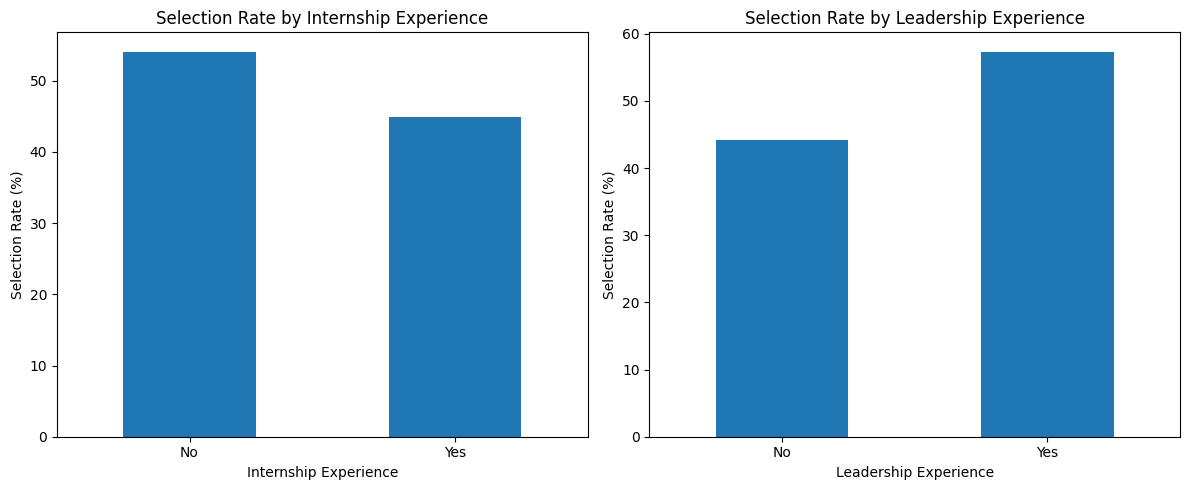

In [129]:
# Visualize internship and leadership experience

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

internship_selection['Selected'].plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Selection Rate by Internship Experience')
axes[0].set_xlabel('Internship Experience')
axes[0].set_ylabel('Selection Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

leadership_selection['Selected'].plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title('Selection Rate by Leadership Experience')
axes[1].set_xlabel('Leadership Experience')
axes[1].set_ylabel('Selection Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [130]:
# Calculate selection rate by country
country_selection = pd.crosstab(
    df['country'],
    df['selected'],
    normalize='index'
) * 100

# Top 10 countries by selection rate
country_selection.sort_values(
    'Selected',
    ascending=False
).head(10)

selected,Rejected,Selected
country,,
Uganda,42.995169,57.004831
Barbados,43.230404,56.769596
Zambia,43.349754,56.650246
Wallis and Futuna,43.564356,56.435644
Mauritius,44.047619,55.952381
Belgium,44.523810,55.476190
Falkland Islands (Malvinas),44.717445,55.282555
Macao,44.827586,55.172414
Luxembourg,44.844125,55.155875


In [131]:
# Bottom 10 countries by selection rate
country_selection.sort_values(
    'Selected',
    ascending=True
).head(10)

selected,Rejected,Selected
country,,
Ukraine,56.430446,43.569554
Switzerland,56.265985,43.734015
Peru,56.109726,43.890274
Saint Pierre and Miquelon,55.555556,44.444444
Comoros,55.257271,44.742729
Myanmar,55.216285,44.783715
Grenada,54.846939,45.153061
Gabon,54.698795,45.301205
Antarctica (the territory South of 60 deg S),54.694836,45.305164


In [132]:
import pandas as pd

In [133]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    '/kaggle/input/datasets/mobeenfatimah/resume-screening-and-ats-hiring-dataset100k-record/ai_resume_screening_dataset.csv'
)

df.head()

,candidate_id,full_name,email,phone,country,city,age,gender,highest_education,university,...,expected_salary,preferred_location,employment_type,remote_preference,availability,resume_quality_score,resume_length,keyword_match_percentage,ats_score,selected
0,CAND-000001,Allison Hill,allison.hill13@gmail.com,+1-959-381-5012,Burundi,Lake Joyside,35,Female,Master,Georgia Institute of Technology,...,172000,Burundi,Internship,Hybrid,30 Days,72,2,20.00,46,Selected
1,CAND-000002,Javier Johnson,javier.johnson58@gmail.com,+1-299-467-6635,Djibouti,New Jamesside,37,Male,Master,National University of Singapore,...,212000,Djibouti,Contract,Remote,Immediate,77,2,20.68,46,Rejected
2,CAND-000003,Jerry Ramirez,jerry.ramirez58@gmail.com,+1-476-755-4598,Senegal,Lake Roberto,41,Male,Bachelor,Massachusetts Institute of Technology,...,193000,Flexible,Full-Time,On-site,Immediate,58,2,62.55,65,Selected
3,CAND-000004,Daniel Gallagher,daniel.gallagher18@gmail.com,+1-594-490-8668,Bermuda,Davisstad,54,Male,PhD,Imperial College London,...,351000,Davisstad,Contract,Hybrid,Immediate,61,1,28.58,43,Selected
4,CAND-000005,Robert Blair,robert.blair40@hotmail.com,+1-780-180-2403,British Virgin Islands,Millerport,52,Male,PhD,National University of Singapore,...,374000,Millerport,Part-Time,Remote,15 Days,62,1,20.00,46,Selected


In [134]:
df.shape

(100000, 44)

In [137]:
# Relationship between Availability and Selection
# This table shows the percentage of candidates selected or rejected
# within each availability category.

availability_selection = pd.crosstab(
    df['availability'],
    df['selected'],
    normalize='index'
) * 100

availability_selection

selected,Rejected,Selected
availability,,
15 Days,50.043045,49.956955
30 Days,49.543593,50.456407
60 Days,49.781811,50.218189
90 Days,50.443409,49.556591
Immediate,50.198882,49.801118


In [138]:
# Relationship between Gender and Selection
# This table shows the percentage of candidates selected or rejected
# within each gender category.

gender_selection = pd.crosstab(
    df['gender'],
    df['selected'],
    normalize='index'
) * 100

gender_selection

selected,Rejected,Selected
gender,,
Female,49.820239,50.179761
Male,50.158821,49.841179
Other,50.517063,49.482937


In [139]:
# Relationship between Field of Study and Selection
# This table shows the percentage of candidates selected or rejected
# within each field of study.

field_selection = pd.crosstab(
    df['field_of_study'],
    df['selected'],
    normalize='index'
) * 100

field_selection.sort_values('Selected', ascending=False)

selected,Rejected,Selected
field_of_study,,
Cyber Security,49.562759,50.437241
Electrical Engineering,49.621144,50.378856
Artificial Intelligence,49.684173,50.315827
Information Technology,49.821874,50.178126
Information Systems,50.035971,49.964029
Mathematics & Statistics,50.057958,49.942042
Computer Science,50.152144,49.847856
Software Engineering,50.238588,49.761412
Data Science,50.845762,49.154238


In [140]:
# Relationship between Current Job Title and Selection
# This table shows the percentage of candidates selected or rejected
# within each current job title.

job_title_selection = pd.crosstab(
    df['current_job_title'],
    df['selected'],
    normalize='index'
) * 100

job_title_selection.sort_values('Selected', ascending=False)

selected,Rejected,Selected
current_job_title,,
QA Engineer,45.863309,54.136691
Business Analyst,45.984252,54.015748
Frontend Developer,46.133458,53.866542
Machine Learning Engineer,46.313652,53.686348
Software Engineer,46.683796,53.316204
AI Engineer,46.876982,53.123018
Full Stack Developer,46.941701,53.058299
Cyber Security Analyst,46.948207,53.051793
Backend Developer,46.992783,53.007217


In [141]:
# Relationship between University and Selection
# This table shows the percentage of candidates selected or rejected
# within each university.

university_selection = pd.crosstab(
    df['university'],
    df['selected'],
    normalize='index'
) * 100

university_selection.sort_values('Selected', ascending=False)

selected,Rejected,Selected
university,,
National University of Singapore,49.213883,50.786117
Stanford University,49.230999,50.769001
University of Toronto,49.517159,50.482841
Carnegie Mellon University,49.601770,50.398230
"University of California, Berkeley",49.724434,50.275566
Tsinghua University,49.772382,50.227618
Harvard University,49.833686,50.166314
Massachusetts Institute of Technology,49.984844,50.015156
Georgia Institute of Technology,50.184720,49.815280


In [142]:
# Exploring Previous Companies
# This helps us understand how previous company information is represented.

df['previous_companies'].value_counts().head(20)

previous_companies
Not Applicable    21356
NVIDIA              969
Palantir            922
Intel               919
Oracle              913
Amazon              906
Uber                901
Microsoft           899
Google              896
IBM                 889
Netflix             888
Apple               888
Stripe              886
Salesforce          883
Snowflake           881
Meta                879
Airbnb              875
Databricks          867
Cisco               863
Adobe               861
Name: count, dtype: int64

In [143]:
# Relationship between Previous Company Experience and Selection
# We first group candidates into those with previous company experience
# and those with no previous company experience.

df['has_previous_company'] = df['previous_companies'].apply(
    lambda x: 'No Previous Company' if x == 'Not Applicable' else 'Has Previous Company'
)

previous_company_selection = pd.crosstab(
    df['has_previous_company'],
    df['selected'],
    normalize='index'
) * 100

previous_company_selection

selected,Rejected,Selected
has_previous_company,,
Has Previous Company,47.015666,52.984334
No Previous Company,60.989886,39.010114


In [144]:
# Check the most common technical skill combinations
# This helps us understand how the technical_skills column is structured
# before creating a meaningful relationship analysis.

df['technical_skills'].value_counts().head(20)

technical_skills
Linux, Python, Express             5
Docker, Redis, Git                 5
Kubernetes, AWS, Redis             4
HTML, Scikit-learn, Angular        4
HTML, Kubernetes, NumPy            4
Pandas, CSS, Docker                4
Node.js, Redis, JavaScript         4
Azure, MySQL, Scikit-learn         4
SQL, Angular, Flask                4
Node.js, Python, PostgreSQL        4
Git, Kubernetes, TensorFlow        4
Pandas, PyTorch, Django            4
MySQL, TypeScript, Azure           4
Linux, Vue, Docker                 4
JavaScript, Kubernetes, Node.js    4
Pandas, C++, HTML                  4
C++, TypeScript, CSS               4
MySQL, Vue, C++                    4
TypeScript, Azure, Django          4
GCP, PyTorch, Angular              4
Name: count, dtype: int64

In [145]:
# Check the most common programming language combinations
# This helps us understand how the programming_languages column is structured
# before deciding how to analyze its relationship with selection.

df['programming_languages'].value_counts().head(20)

programming_languages
Not Applicable            30900
Python                     8334
Java                       8194
C++                        8185
TypeScript                 8066
JavaScript                 8052
Java, C++                  1121
Python, JavaScript         1119
TypeScript, C++            1117
JavaScript, C++            1112
Java, JavaScript           1108
JavaScript, TypeScript     1102
Java, Python               1101
C++, TypeScript            1094
Java, TypeScript           1092
TypeScript, Java           1085
C++, Python                1085
JavaScript, Java           1080
Python, Java               1078
JavaScript, Python         1077
Name: count, dtype: int64

In [146]:
# Create a simple grouping to identify whether a candidate has
# any programming language listed in their profile.

df['has_programming_language'] = df['programming_languages'].apply(
    lambda x: 'No Programming Language' if x == 'Not Applicable'
    else 'Has Programming Language'
)

# Calculate the percentage of candidates selected and rejected
# within each programming-language group.

programming_selection = pd.crosstab(
    df['has_programming_language'],
    df['selected'],
    normalize='index'
) * 100

programming_selection

selected,Rejected,Selected
has_programming_language,,
Has Programming Language,49.005789,50.994211
No Programming Language,52.223301,47.776699


In [147]:
# Check the most common framework combinations
# This helps us understand how the frameworks column is structured
# before deciding on an appropriate grouping for the analysis.

df['frameworks'].value_counts().head(20)

frameworks
Not Applicable         9953
Node.js                2656
React                  2651
Flask                  2632
Scikit-learn           2630
Vue                    2560
TensorFlow             2540
Django                 2512
PyTorch                2493
Express                2492
Angular                2488
React, Scikit-learn     364
Vue, Scikit-learn       362
Flask, Node.js          362
PyTorch, TensorFlow     360
Express, Vue            357
Django, Express         356
PyTorch, Node.js        352
Express, Django         351
Flask, Django           351
Name: count, dtype: int64

In [148]:
# Create a simple grouping to identify whether a candidate
# has any framework listed in their profile.

df['has_framework'] = df['frameworks'].apply(
    lambda x: 'No Framework' if x == 'Not Applicable'
    else 'Has Framework'
)

# Calculate the percentage of candidates selected and rejected
# within each framework group.

framework_selection = pd.crosstab(
    df['has_framework'],
    df['selected'],
    normalize='index'
) * 100

framework_selection

selected,Rejected,Selected
has_framework,,
Has Framework,49.785112,50.214888
No Framework,51.944137,48.055863


In [149]:
# Check the most common database combinations
# This helps us understand how the databases column is structured
# before deciding on an appropriate grouping for the analysis.

df['databases'].value_counts().head(20)

databases
Not Applicable         31091
SQL                     8340
PostgreSQL              8286
Redis                   8220
MongoDB                 8064
MySQL                   8037
MySQL, PostgreSQL       1123
Redis, MongoDB          1122
MySQL, Redis            1110
MySQL, SQL              1109
MongoDB, SQL            1097
MongoDB, PostgreSQL     1095
MongoDB, Redis          1087
SQL, Redis              1080
Redis, PostgreSQL       1078
PostgreSQL, MySQL       1076
MongoDB, MySQL          1070
SQL, MongoDB            1060
MySQL, MongoDB          1060
SQL, MySQL              1059
Name: count, dtype: int64

In [150]:
# Create a simple grouping to identify whether a candidate
# has any database experience listed in their profile.

df['has_database'] = df['databases'].apply(
    lambda x: 'No Database' if x == 'Not Applicable'
    else 'Has Database'
)

# Calculate the percentage of candidates selected and rejected
# within each database-experience group.

database_selection = pd.crosstab(
    df['has_database'],
    df['selected'],
    normalize='index'
) * 100

database_selection

selected,Rejected,Selected
has_database,,
Has Database,49.539247,50.460753
No Database,51.021196,48.978804


In [151]:
# Check the most common cloud platform values
# This helps us understand how the cloud_platform column is structured
# before creating a meaningful grouping for the analysis.

df['cloud_platform'].value_counts().head(20)

cloud_platform
Not Applicable        31035
AWS                    8185
GCP                    8174
Azure                  8151
Docker                 8127
Kubernetes             8070
Kubernetes, Docker     1152
Docker, GCP            1150
AWS, Docker            1148
GCP, Kubernetes        1129
Azure, AWS             1103
Azure, GCP             1093
Kubernetes, AWS        1092
AWS, GCP               1088
GCP, AWS               1087
Docker, Kubernetes     1084
GCP, Azure             1082
Docker, Azure          1076
Azure, Docker          1072
GCP, Docker            1071
Name: count, dtype: int64

In [152]:
# Create a simple grouping to identify whether a candidate
# has any cloud platform experience listed in their profile.

df['has_cloud_platform'] = df['cloud_platform'].apply(
    lambda x: 'No Cloud Platform' if x == 'Not Applicable'
    else 'Has Cloud Platform'
)

# Calculate the percentage of candidates selected and rejected
# within each cloud-platform experience group.

cloud_selection = pd.crosstab(
    df['has_cloud_platform'],
    df['selected'],
    normalize='index'
) * 100

cloud_selection

selected,Rejected,Selected
has_cloud_platform,,
Has Cloud Platform,49.461321,50.538679
No Cloud Platform,51.197036,48.802964


In [153]:
# Check the most common certification values
# This helps us understand how the certifications column is structured
# before deciding how to analyze its relationship with selection.

df['certifications'].value_counts().head(20)

certifications
Not Applicable                                                                                           40127
AWS Certified Developer                                                                                   3581
Google Cloud Professional Data Engineer                                                                   3576
Certified Information Systems Security Professional (CISSP)                                               3572
TensorFlow Developer Certificate                                                                          3546
HashiCorp Certified: Terraform Associate                                                                  3516
Certified Kubernetes Administrator (CKA)                                                                  3506
Oracle Certified Professional Java SE                                                                     3488
AWS Certified Solutions Architect                                                                

In [154]:
# Create a simple grouping to identify whether a candidate
# has any certification listed in their profile.

df['has_certification'] = df['certifications'].apply(
    lambda x: 'No Certification' if x == 'Not Applicable'
    else 'Has Certification'
)

# Calculate the percentage of candidates selected and rejected
# within each certification group.

certification_selection = pd.crosstab(
    df['has_certification'],
    df['selected'],
    normalize='index'
) * 100

certification_selection

selected,Rejected,Selected
has_certification,,
Has Certification,49.932357,50.067643
No Certification,50.100930,49.899070


In [155]:
# Calculate the percentage of candidates selected and rejected
# for each number of publications.

publication_selection = pd.crosstab(
    df['publications'],
    df['selected'],
    normalize='index'
) * 100

publication_selection

selected,Rejected,Selected
publications,,
0,50.087986,49.912014
1,49.643214,50.356786
2,49.828816,50.171184
3,49.983238,50.016762


In [156]:
# Calculate the percentage of candidates selected and rejected
# for each number of completed projects.

projects_selection = pd.crosstab(
    df['projects_completed'],
    df['selected'],
    normalize='index'
) * 100

projects_selection

selected,Rejected,Selected
projects_completed,,
1,51.119626,48.880374
2,50.113759,49.886241
3,50.806548,49.193452
4,49.753754,50.246246
5,50.393701,49.606299
6,49.028896,50.971104
7,49.116651,50.883349
8,49.675090,50.324910
9,49.428055,50.571945


In [157]:
# Compare CGPA statistics between selected and rejected candidates
# to determine whether academic performance differs between the two groups.

cgpa_selection = df.groupby('selected')['cgpa'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

cgpa_selection

,count,mean,median,std,min,max
selected,,,,,,
Rejected,50000,3.189266,3.16,0.430094,2.5,4.0
Selected,50000,3.307416,3.33,0.428637,2.5,4.0


In [159]:
# Compare age statistics between selected and rejected candidates
# to determine whether age differs between the two selection groups.

age_selection = df.groupby('selected')['age'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

age_selection

,count,mean,median,std,min,max
selected,,,,,,
Rejected,50000,32.28078,30.0,9.388897,21,55
Selected,50000,43.70484,44.0,7.102192,21,55


In [160]:
# Compare expected salary statistics between selected and rejected candidates
# to determine whether salary expectations differ between the two groups.

salary_selection = df.groupby('selected')['expected_salary'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

salary_selection

,count,mean,median,std,min,max
selected,,,,,,
Rejected,50000,141562.38,125000.0,61231.114425,45000,398000
Selected,50000,212809.40,212000.0,50679.431328,56000,401000


In [161]:
# Calculate the percentage of candidates selected and rejected
# for each resume-length category.

resume_length_selection = pd.crosstab(
    df['resume_length'],
    df['selected'],
    normalize='index'
) * 100

resume_length_selection

selected,Rejected,Selected
resume_length,,
1,50.086280,49.913720
2,50.181320,49.818680
3,49.772430,50.227570
4,49.963994,50.036006


In [162]:
# Select the main assessment and resume-related score variables
# that may be associated with candidate selection.

score_columns = [
    'communication_score',
    'problem_solving_score',
    'technical_test_score',
    'interview_score',
    'aptitude_score',
    'resume_quality_score',
    'keyword_match_percentage',
    'ats_score'
]

# Calculate the mean of each score for selected and rejected candidates.
# This creates one table that allows us to compare the groups directly.

score_selection = df.groupby('selected')[score_columns].mean().round(2)

score_selection

,communication_score,problem_solving_score,technical_test_score,interview_score,aptitude_score,resume_quality_score,keyword_match_percentage,ats_score
selected,,,,,,,,
Rejected,68.65,70.03,64.61,66.94,69.84,73.77,26.13,49.83
Selected,70.22,72.80,70.04,71.80,70.93,75.30,30.05,52.64


In [163]:
# Compare graduation year statistics between selected and rejected candidates
# to determine whether graduation year differs between the two groups.

graduation_selection = df.groupby('selected')['graduation_year'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

graduation_selection

,count,mean,median,std,min,max
selected,,,,,,
Rejected,50000,2014.69450,2017.0,9.382495,1989,2026
Selected,50000,2003.19852,2003.0,7.161518,1989,2026


## Overall EDA Relationship Summary

The exploratory data analysis was conducted to understand how candidate characteristics, qualifications, experience, assessment performance, resume-related metrics, technical skills, and employment preferences relate to candidate selection.

The target variable, `selected`, is perfectly balanced, with 50% of candidates selected and 50% rejected. Therefore, there is no class imbalance that needs to be addressed before modelling.

### 1. Experience, Age and Graduation Year

Experience showed one of the strongest relationships with candidate selection. Selection increased sharply as experience increased from 0 years to approximately 15 years. After around 15 years of experience, the selection rate remained relatively stable at approximately 75–79%.

Age showed a similar strong relationship with selection. Selected candidates had an average age of approximately 43.70 years, compared with 32.28 years for rejected candidates. However, age should not be considered independently because age and experience are very strongly correlated (approximately 0.99).

Graduation year showed an opposite relationship. Selected candidates had an average graduation year of approximately 2003, while rejected candidates averaged approximately 2015. Graduation year was also almost perfectly negatively correlated with experience (-1.00). This suggests that the relationship between graduation year and selection is largely connected to experience.

### 2. Expected Salary

Expected salary showed a strong association with selection. Selected candidates had an average expected salary of approximately 212,809, compared with approximately 141,562 for rejected candidates.

Expected salary was also strongly correlated with experience (approximately 0.94) and age (approximately 0.93). Therefore, the higher salary values among selected candidates may partly reflect their greater experience rather than salary independently influencing selection.

### 3. Education and Academic Background

Highest education level showed very little difference in selection rates. Selection rates across Diploma, High School, Bachelor, Master and PhD candidates were all close to 50%.

University and field of study also showed only small differences in selection rates. The variation between universities and fields of study was relatively small, suggesting that these variables alone have weak relationships with selection in this dataset.

CGPA showed a more noticeable association. Selected candidates had an average CGPA of approximately 3.31, compared with 3.19 among rejected candidates. This suggests that academic performance may contribute to selection, although further statistical testing is required to determine whether the difference is statistically significant.

### 4. Assessment Performance

Assessment scores showed some of the clearest differences between selected and rejected candidates.

Selected candidates had higher average scores across all major assessment measures:

- Communication: 70.22 vs 68.65
- Problem solving: 72.80 vs 70.03
- Technical test: 70.04 vs 64.61
- Interview: 71.80 vs 66.94
- Aptitude: 70.93 vs 69.84

The largest differences were observed in the technical test and interview scores. This suggests that technical performance and interview performance may be more strongly associated with selection than communication and aptitude scores.

### 5. Resume and ATS-related Metrics

Selected candidates generally had higher ATS-related scores:

- ATS score: 52.64 vs 49.83
- Keyword match percentage: 30.05 vs 26.13
- Resume quality score: 75.30 vs 73.77

The largest difference was observed in keyword match percentage, followed by ATS score. Resume quality showed a smaller difference.

Keyword match percentage and ATS score were also positively correlated (approximately 0.70), while resume quality and ATS score had a correlation of approximately 0.62. This suggests that these resume-related measures capture related aspects of ATS performance.

### 6. Work Experience and Professional Background

Previous company experience showed a meaningful association with selection. Candidates with previous company experience had a selection rate of approximately 52.98%, compared with 39.01% for candidates with no previous company experience.

Internship experience also showed a noticeable difference. Candidates with internship experience had a selection rate of approximately 55.04%, compared with 45.91% among those without internship experience.

Leadership experience showed an even stronger difference. Candidates with leadership experience had a selection rate of approximately 57.35%, compared with 44.17% for candidates without leadership experience.

These relationships suggest that practical and leadership experience may be useful indicators of selection. However, these variables may also be related to overall experience, so they should not automatically be interpreted as independent causes of selection.

### 7. Technical Skills

Having programming languages, frameworks, databases, or cloud-platform experience showed only weak positive associations with selection.

The approximate selection differences were:

- Programming language: 50.99% with vs 47.78% without
- Framework: 50.21% with vs 48.06% without
- Database: 50.46% with vs 48.98% without
- Cloud platform: 50.54% with vs 48.80% without

Certifications showed almost no difference, with selection rates of approximately 50.07% for candidates with certifications and 49.90% for candidates without certifications.

Publications and number of projects completed also showed little or no meaningful relationship with selection.

### 8. Current Job Title and Job Role

Job role showed very small differences in selection rates, with most roles remaining close to 50%. Therefore, job role alone does not appear to be a strong predictor of selection.

Current job title showed a different pattern because most actual job titles had selection rates between approximately 52% and 54%, while the `Entry Level / Unemployed` category had an extremely low selection rate of approximately 0.1%.

This large difference is likely connected to the candidate's lack of professional experience rather than the job title itself.

### 9. Employment Preferences and Availability

Employment type showed almost identical selection rates across Contract, Full-Time, Internship and Part-Time candidates.

Remote preference also showed virtually no difference between Remote, Hybrid and On-site candidates.

Availability showed similarly small differences. Selection rates across Immediate, 15 Days, 30 Days, 60 Days and 90 Days were all approximately 50%.

These variables therefore appear to have weak relationships with selection in this dataset.

### 10. Demographic and Geographic Variables

Gender showed almost identical selection rates across Female, Male and Other categories, with differences of less than one percentage point.

Country showed more variation, with some countries having selection rates above 55% and others below 45%. However, there are 243 country categories, and differences may partly reflect differences in subgroup sizes. Therefore, country-level differences should be interpreted cautiously.

### 11. Variables Showing the Strongest Relationships

Based on the exploratory analysis and correlation results, the variables showing the strongest associations with selection were:

1. Experience years
2. Age
3. Expected salary
4. Graduation year
5. Technical test score
6. Interview score
7. ATS score
8. Keyword match percentage
9. CGPA
10. Leadership experience
11. Internship experience
12. Previous company experience

The strongest numerical correlations with selection were approximately:

- Experience: 0.57
- Age: 0.57
- Expected salary: 0.54
- Graduation year: -0.57
- Technical test score: 0.17
- Interview score: 0.17
- ATS score: 0.16
- Keyword match percentage: 0.16

### Overall Conclusion

Overall, the EDA suggests that candidate selection is most strongly associated with professional experience, age-related experience patterns, expected salary, assessment performance, and selected resume/ATS metrics.

Technical test and interview performance showed particularly noticeable differences between selected and rejected candidates. Leadership, internship and previous company experience also showed meaningful differences.

In contrast, education level, university, field of study, employment type, remote preference, availability, gender, certifications, publications, projects completed, frameworks, databases and cloud-platform experience showed relatively weak relationships with selection.

It is important to note that these findings describe associations observed in the dataset and do not establish causation. Some variables are also highly correlated with one another, particularly age, experience and graduation year. Statistical hypothesis testing will therefore be used next to determine which observed relationships are statistically significant.

# Hypothesis Testing

After completing the exploratory data analysis, hypothesis testing is used to determine whether the relationships observed between candidate characteristics and selection are statistically significant.

The null hypothesis (H₀) assumes that there is no statistically significant relationship or difference between the variable being tested and candidate selection.

The alternative hypothesis (H₁) assumes that a statistically significant relationship or difference exists.

A significance level of 5% (α = 0.05) will be used. Therefore:

- If p-value < 0.05, we reject H₀.
- If p-value ≥ 0.05, we fail to reject H₀.

The statistical test used will depend on the type and distribution of each variable.

In [164]:
# Import the Mann-Whitney U test.
# This test compares the distributions of a numerical variable
# between two independent groups: Selected and Rejected.

from scipy.stats import mannwhitneyu

# Define the numerical variables that showed important relationships
# during the exploratory data analysis.

test_variables = [
    'experience_years',
    'age',
    'expected_salary',
    'cgpa',
    'technical_test_score',
    'interview_score',
    'problem_solving_score',
    'ats_score',
    'keyword_match_percentage',
    'resume_quality_score'
]

# Create an empty list to store the hypothesis-testing results.
results = []

# Run the Mann-Whitney U test for each variable.
for variable in test_variables:
    
    # Extract values for rejected candidates.
    rejected = df.loc[df['selected'] == 'Rejected', variable]
    
    # Extract values for selected candidates.
    selected = df.loc[df['selected'] == 'Selected', variable]
    
    # Perform the two-sided Mann-Whitney U test.
    statistic, p_value = mannwhitneyu(
        rejected,
        selected,
        alternative='two-sided'
    )
    
    # Store the test results.
    results.append({
        'Variable': variable,
        'U Statistic': statistic,
        'P-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# Convert the results into a DataFrame for easy interpretation.
hypothesis_results = pd.DataFrame(results)

# Display the results.
hypothesis_results

,Variable,U Statistic,P-value,Significant
0,experience_years,4.260202e+08,0.000000e+00,Yes
1,age,4.332114e+08,0.000000e+00,Yes
2,expected_salary,4.548239e+08,0.000000e+00,Yes
3,cgpa,1.053229e+09,0.000000e+00,Yes
4,technical_test_score,1.003953e+09,0.000000e+00,Yes
5,interview_score,1.014263e+09,0.000000e+00,Yes
6,problem_solving_score,1.106304e+09,1.207017e-217,Yes
7,ats_score,1.025733e+09,0.000000e+00,Yes
8,keyword_match_percentage,1.055044e+09,0.000000e+00,Yes
9,resume_quality_score,1.155578e+09,3.968833e-95,Yes


In [165]:
# Format the hypothesis-testing results so that extremely small p-values
# are displayed clearly instead of appearing as exactly zero.

hypothesis_results_display = hypothesis_results.copy()

hypothesis_results_display['P-value'] = hypothesis_results_display['P-value'].apply(
    lambda x: f"{x:.2e}" if x > 0 else "< 1e-300"
)

hypothesis_results_display

,Variable,U Statistic,P-value,Significant
0,experience_years,4.260202e+08,< 1e-300,Yes
1,age,4.332114e+08,< 1e-300,Yes
2,expected_salary,4.548239e+08,< 1e-300,Yes
3,cgpa,1.053229e+09,< 1e-300,Yes
4,technical_test_score,1.003953e+09,< 1e-300,Yes
5,interview_score,1.014263e+09,< 1e-300,Yes
6,problem_solving_score,1.106304e+09,1.21e-217,Yes
7,ats_score,1.025733e+09,< 1e-300,Yes
8,keyword_match_percentage,1.055044e+09,< 1e-300,Yes
9,resume_quality_score,1.155578e+09,3.97e-95,Yes


In [166]:
# Import the Chi-Square test of independence.
# This test is appropriate for examining relationships between
# categorical variables and the categorical selection outcome.

from scipy.stats import chi2_contingency

# Select the categorical variables that showed potentially
# meaningful or relevant relationships during EDA.

categorical_variables = [
    'highest_education',
    'gender',
    'internship_experience',
    'leadership_experience',
    'employment_type',
    'remote_preference',
    'availability',
    'job_role',
    'field_of_study',
    'current_job_title',
    'has_previous_company',
    'has_programming_language',
    'has_framework',
    'has_database',
    'has_cloud_platform',
    'has_certification',
    'publications',
    'projects_completed'
]

# Create an empty list to store the Chi-Square test results.
chi_square_results = []

# Run the Chi-Square test for each categorical variable.
for variable in categorical_variables:
    
    # Create a contingency table showing the frequency
    # of selected and rejected candidates in each category.
    contingency_table = pd.crosstab(
        df[variable],
        df['selected']
    )
    
    # Perform the Chi-Square test of independence.
    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
        contingency_table
    )
    
    # Store the test results.
    chi_square_results.append({
        'Variable': variable,
        'Chi-Square Statistic': chi2,
        'Degrees of Freedom': degrees_of_freedom,
        'P-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# Convert the results into a DataFrame.
chi_square_results = pd.DataFrame(chi_square_results)

# Display the results.
chi_square_results

,Variable,Chi-Square Statistic,Degrees of Freedom,P-value,Significant
0,highest_education,8.984822,4,6.147998e-02,No
1,gender,1.335103,2,5.129630e-01,No
2,internship_experience,824.617409,1,2.398245e-181,Yes
3,leadership_experience,1715.917172,1,0.000000e+00,Yes
4,employment_type,0.139668,3,9.866851e-01,No
5,remote_preference,0.923703,2,6.301158e-01,No
6,availability,3.971255,4,4.099100e-01,No
7,job_role,16.862963,14,2.635542e-01,No
8,field_of_study,5.607252,8,6.911306e-01,No
9,current_job_title,6026.502683,15,0.000000e+00,Yes


In [167]:
# Format very small p-values so that the Chi-Square results
# are easier to read and interpret in the final analysis.

chi_square_results_display = chi_square_results.copy()

chi_square_results_display['P-value'] = chi_square_results_display['P-value'].apply(
    lambda x: f"{x:.2e}" if x > 0 else "< 1e-300"
)

chi_square_results_display

,Variable,Chi-Square Statistic,Degrees of Freedom,P-value,Significant
0,highest_education,8.984822,4,6.15e-02,No
1,gender,1.335103,2,5.13e-01,No
2,internship_experience,824.617409,1,2.40e-181,Yes
3,leadership_experience,1715.917172,1,< 1e-300,Yes
4,employment_type,0.139668,3,9.87e-01,No
5,remote_preference,0.923703,2,6.30e-01,No
6,availability,3.971255,4,4.10e-01,No
7,job_role,16.862963,14,2.64e-01,No
8,field_of_study,5.607252,8,6.91e-01,No
9,current_job_title,6026.502683,15,< 1e-300,Yes


In [168]:
# Calculate Cramér's V for the categorical variables tested above.
# Cramér's V measures the strength of association between
# each categorical variable and candidate selection.

import numpy as np

# Create an empty list to store the effect-size results.
cramers_results = []

# Calculate Cramér's V for each categorical variable.
for variable in categorical_variables:
    
    # Create a contingency table between the variable and selection.
    contingency_table = pd.crosstab(
        df[variable],
        df['selected']
    )
    
    # Perform the Chi-Square test.
    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
        contingency_table
    )
    
    # Get the total number of observations.
    n = contingency_table.sum().sum()
    
    # Find the smaller dimension of the contingency table.
    min_dimension = min(
        contingency_table.shape[0] - 1,
        contingency_table.shape[1] - 1
    )
    
    # Calculate Cramér's V.
    cramers_v = np.sqrt(
        chi2 / (n * min_dimension)
    )
    
    # Store the variable and effect-size result.
    cramers_results.append({
        'Variable': variable,
        "Cramer's V": cramers_v
    })

# Convert the results into a DataFrame.
cramers_results = pd.DataFrame(cramers_results)

# Sort the variables from strongest to weakest association.
cramers_results = cramers_results.sort_values(
    "Cramer's V",
    ascending=False
)

# Round the effect sizes for easier interpretation.
cramers_results["Cramer's V"] = cramers_results["Cramer's V"].round(4)

# Display the results.
cramers_results

,Variable,Cramer's V
9,current_job_title,0.2455
3,leadership_experience,0.1310
10,has_previous_company,0.1145
2,internship_experience,0.0908
11,has_programming_language,0.0297
14,has_cloud_platform,0.0160
13,has_database,0.0137
7,job_role,0.0130
12,has_framework,0.0129
17,projects_completed,0.0128


In [169]:
# Calculate Cohen's d for the numerical variables tested earlier.
# Cohen's d measures the standardized difference between
# selected and rejected candidates.

cohens_results = []

for variable in test_variables:
    
    # Extract the numerical values for each selection group.
    rejected = df.loc[df['selected'] == 'Rejected', variable]
    selected = df.loc[df['selected'] == 'Selected', variable]
    
    # Calculate the sample sizes.
    n_rejected = len(rejected)
    n_selected = len(selected)
    
    # Calculate the standard deviations.
    sd_rejected = rejected.std()
    sd_selected = selected.std()
    
    # Calculate the pooled standard deviation.
    pooled_sd = np.sqrt(
        (
            (n_rejected - 1) * sd_rejected**2
            + (n_selected - 1) * sd_selected**2
        )
        / (n_rejected + n_selected - 2)
    )
    
    # Calculate Cohen's d.
    cohen_d = (
        selected.mean() - rejected.mean()
    ) / pooled_sd
    
    # Store the result.
    cohens_results.append({
        'Variable': variable,
        "Cohen's d": cohen_d
    })

# Convert the results into a DataFrame.
cohens_results = pd.DataFrame(cohens_results)

# Sort from the largest standardized difference to the smallest.
cohens_results = cohens_results.sort_values(
    "Cohen's d",
    ascending=False
)

# Round the results for easier interpretation.
cohens_results["Cohen's d"] = cohens_results["Cohen's d"].round(4)

cohens_results

,Variable,Cohen's d
0,experience_years,1.3844
1,age,1.3724
2,expected_salary,1.2677
4,technical_test_score,0.3507
5,interview_score,0.3357
7,ats_score,0.3318
8,keyword_match_percentage,0.3167
3,cgpa,0.2752
6,problem_solving_score,0.2025
9,resume_quality_score,0.1326


In [172]:
# Create experience groups so that we can examine whether
# selection rates differ across meaningful experience levels.

df['experience_group'] = pd.cut(
    df['experience_years'],
    bins=[-1, 5, 10, 15, 20, 25, 30, 35],
    labels=[
        '0-5 years',
        '6-10 years',
        '11-15 years',
        '16-20 years',
        '21-25 years',
        '26-30 years',
        '31-35 years'
    ]
)

# Create a contingency table showing the number of selected
# and rejected candidates in each experience group.

experience_contingency = pd.crosstab(
    df['experience_group'],
    df['selected']
)

# Display the counts for each experience group.
experience_contingency

selected,Rejected,Selected
experience_group,,
0-5 years,19640,285
6-10 years,11836,2457
11-15 years,6154,8358
16-20 years,3442,10783
21-25 years,3430,10825
26-30 years,3500,10693
31-35 years,1998,6599


In [173]:
# Test whether candidate experience groups are statistically associated
# with selection using the Chi-Square Test of Independence.

experience_chi2_table = pd.crosstab(
    df['experience_group'],
    df['selected']
)

# Perform the Chi-Square test.
experience_chi2, experience_p, experience_dof, experience_expected = chi2_contingency(
    experience_chi2_table
)

# Display the test results.
experience_test_result = pd.DataFrame({
    'Test': ['Chi-Square Test'],
    'Chi-Square Statistic': [experience_chi2],
    'Degrees of Freedom': [experience_dof],
    'P-value': [experience_p],
    'Significant': ['Yes' if experience_p < 0.05 else 'No']
})

experience_test_result

,Test,Chi-Square Statistic,Degrees of Freedom,P-value,Significant
0,Chi-Square Test,39022.983504,6,0.0,Yes


In [174]:
# Calculate Cramér's V for the experience groups.
# This measures the strength of the association between
# experience group and candidate selection.

n = experience_chi2_table.sum().sum()

min_dimension = min(
    experience_chi2_table.shape[0] - 1,
    experience_chi2_table.shape[1] - 1
)

experience_cramers_v = np.sqrt(
    experience_chi2 / (n * min_dimension)
)

# Display the experience effect size.
experience_effect_size = pd.DataFrame({
    'Variable': ['experience_group'],
    "Cramer's V": [round(experience_cramers_v, 4)]
})

experience_effect_size

,Variable,Cramer's V
0,experience_group,0.6247


# Hypothesis Testing and Statistical Analysis

After completing the exploratory data analysis, statistical hypothesis testing was performed to determine whether the relationships observed between candidate characteristics and selection were statistically significant.

A significance level of 5% (α = 0.05) was used throughout the analysis. A p-value below 0.05 was considered evidence against the null hypothesis.

## Numerical Variables

The Mann-Whitney U test was used to compare numerical variables between selected and rejected candidates.

All ten numerical variables tested were statistically significant:

- Experience years: p < 1e-300
- Age: p < 1e-300
- Expected salary: p < 1e-300
- CGPA: p < 1e-300
- Technical test score: p < 1e-300
- Interview score: p < 1e-300
- Problem-solving score: p = 1.21e-217
- ATS score: p < 1e-300
- Keyword match percentage: p < 1e-300
- Resume quality score: p = 3.97e-95

Therefore, the null hypothesis of no difference between selected and rejected candidates was rejected for all ten numerical variables.

However, statistical significance alone does not indicate the practical importance of a relationship. Cohen's d was therefore used to measure the standardized differences between the two groups.

The largest effect sizes were observed for:

- Experience years: 1.3844
- Age: 1.3724
- Expected salary: 1.2677
- Technical test score: 0.3507
- Interview score: 0.3357
- ATS score: 0.3318
- Keyword match percentage: 0.3167
- CGPA: 0.2752
- Problem-solving score: 0.2025
- Resume quality score: 0.1326

This indicates that experience, age and expected salary have substantially larger standardized differences between selected and rejected candidates than the assessment and resume-related variables.

The strong relationships involving age, experience and salary should be interpreted together because these variables are highly correlated. Age and experience had a correlation of approximately 0.99, while experience and expected salary had a correlation of approximately 0.94.

## Categorical Variables

The Chi-Square Test of Independence was used to determine whether categorical variables were associated with candidate selection.

Statistically significant associations were found for:

- Internship experience
- Leadership experience
- Current job title
- Previous company experience
- Programming language
- Framework
- Database
- Cloud platform

No statistically significant association was found for:

- Highest education
- Gender
- Employment type
- Remote preference
- Availability
- Job role
- Field of study
- Certifications
- Publications
- Projects completed

Cramér's V was used to measure the strength of the categorical associations.

The strongest associations were:

- Current job title: 0.2455
- Leadership experience: 0.1310
- Previous company experience: 0.1145
- Internship experience: 0.0908

The remaining categorical variables had relatively small Cramér's V values, indicating weaker associations with selection even when some of them were statistically significant.

## Experience Group Analysis

Because experience showed the strongest numerical relationship with selection, experience years were grouped into seven categories:

- 0–5 years
- 6–10 years
- 11–15 years
- 16–20 years
- 21–25 years
- 26–30 years
- 31–35 years

A Chi-Square Test of Independence showed a statistically significant association between experience group and candidate selection:

- Chi-Square statistic = 39,022.98
- Degrees of freedom = 6
- p-value < 0.001

Therefore, the null hypothesis of no association between experience group and selection was rejected.

The strength of this relationship was measured using Cramér's V, which produced a value of 0.6247. This was substantially stronger than the categorical associations observed for the other variables.

The experience-group analysis also showed a clear practical pattern. Selection rates were very low among candidates with 0–5 years of experience, increased considerably through the 11–15 and 16–20 year groups, and remained relatively high among candidates with more experience.

## Overall Statistical Conclusion

The hypothesis-testing results support many of the relationships identified during EDA.

The strongest evidence is associated with professional experience, followed by age and expected salary. Assessment-related variables such as technical test score, interview score, ATS score and keyword match percentage also showed statistically significant differences and meaningful effect sizes.

Leadership experience, previous company experience and internship experience showed the strongest categorical relationships after current job title.

At the same time, several variables that might intuitively appear relevant to recruitment—such as highest education, gender, employment type, remote preference, availability, certifications, publications and number of projects—did not show statistically significant associations with selection in this dataset.

It is important to distinguish statistical significance from practical importance. Because the dataset contains 100,000 observations, even relatively small differences can produce very small p-values. Effect-size measures such as Cohen's d and Cramér's V were therefore considered alongside the hypothesis-test results.

Finally, statistical association does not imply causation. In particular, the strong relationships among age, experience, graduation year and expected salary indicate that some variables may be capturing the same underlying characteristic: professional experience.

In [175]:
# Display all dataset columns so we can review which variables
# should be retained, transformed, or removed before modelling.

df.columns.tolist()

['candidate_id',
 'full_name',
 'email',
 'phone',
 'country',
 'city',
 'age',
 'gender',
 'highest_education',
 'university',
 'field_of_study',
 'cgpa',
 'graduation_year',
 'experience_years',
 'previous_companies',
 'current_job_title',
 'internship_experience',
 'leadership_experience',
 'technical_skills',
 'programming_languages',
 'frameworks',
 'databases',
 'cloud_platform',
 'projects_completed',
 'github_profile',
 'linkedin_profile',
 'certifications',
 'publications',
 'communication_score',
 'problem_solving_score',
 'technical_test_score',
 'interview_score',
 'aptitude_score',
 'job_role',
 'expected_salary',
 'preferred_location',
 'employment_type',
 'remote_preference',
 'availability',
 'resume_quality_score',
 'resume_length',
 'keyword_match_percentage',
 'ats_score',
 'selected',
 'has_previous_company',
 'has_programming_language',
 'has_framework',
 'has_database',
 'has_cloud_platform',
 'has_certification',
 'experience_group']

In [177]:
# Categorize the dataset columns according to their role in machine learning.
# This helps us identify identifiers, personal information, target variables,
# useful predictors, and engineered variables before building the model.

identifier_columns = [
    'candidate_id',
    'full_name',
    'email',
    'phone',
    'github_profile',
    'linkedin_profile'
]

target_column = 'selected'

engineered_columns = [
    'has_previous_company',
    'has_programming_language',
    'has_framework',
    'has_database',
    'has_cloud_platform',
    'has_certification',
    'experience_group'
]

# Display the identified groups.
print("Identifier / Personal Information Columns:")
print(identifier_columns)

print("\nTarget Column:")
print(target_column)

print("\nEngineered Columns:")
print(engineered_columns)

Identifier / Personal Information Columns:
['candidate_id', 'full_name', 'email', 'phone', 'github_profile', 'linkedin_profile']

Target Column:
selected

Engineered Columns:
['has_previous_company', 'has_programming_language', 'has_framework', 'has_database', 'has_cloud_platform', 'has_certification', 'experience_group']


In [178]:
# Calculate the number of unique values for each remaining column.
# This helps identify low-cardinality categorical variables that can
# be safely one-hot encoded and high-cardinality variables that need
# special treatment or exclusion.

feature_columns = [
    column for column in df.columns
    if column not in identifier_columns + [target_column]
]

# Calculate the number of unique values for every potential feature.
cardinality = df[feature_columns].nunique().sort_values(ascending=False)

# Display the unique-value counts.
cardinality.to_frame(name='Unique Values')

,Unique Values
technical_skills,97372
city,37950
previous_companies,34104
preferred_location,15831
frameworks,8998
keyword_match_percentage,5549
certifications,821
expected_salary,345
country,243
programming_languages,235


In [180]:
import pandas as pd
import numpy as np

In [181]:
# Create experience groups for analysis.
# These groups help us examine how selection rates change
# across different levels of work experience.

df['experience_group'] = pd.cut(
    df['experience_years'],
    bins=[-1, 5, 10, 15, 20, 25, 30, 35],
    labels=[
        '0-5 years',
        '6-10 years',
        '11-15 years',
        '16-20 years',
        '21-25 years',
        '26-30 years',
        '31-35 years'
    ]
)

# Check that the new column was created successfully.
df[['experience_years', 'experience_group']].head()

,experience_years,experience_group
0,14,11-15 years
1,17,16-20 years
2,21,21-25 years
3,32,31-35 years
4,32,31-35 years


In [182]:
df = pd.read_csv(
    '/kaggle/input/datasets/mobeenfatimah/resume-screening-and-ats-hiring-dataset100k-record/ai_resume_screening_dataset.csv'
)

df.head()

,candidate_id,full_name,email,phone,country,city,age,gender,highest_education,university,...,expected_salary,preferred_location,employment_type,remote_preference,availability,resume_quality_score,resume_length,keyword_match_percentage,ats_score,selected
0,CAND-000001,Allison Hill,allison.hill13@gmail.com,+1-959-381-5012,Burundi,Lake Joyside,35,Female,Master,Georgia Institute of Technology,...,172000,Burundi,Internship,Hybrid,30 Days,72,2,20.00,46,Selected
1,CAND-000002,Javier Johnson,javier.johnson58@gmail.com,+1-299-467-6635,Djibouti,New Jamesside,37,Male,Master,National University of Singapore,...,212000,Djibouti,Contract,Remote,Immediate,77,2,20.68,46,Rejected
2,CAND-000003,Jerry Ramirez,jerry.ramirez58@gmail.com,+1-476-755-4598,Senegal,Lake Roberto,41,Male,Bachelor,Massachusetts Institute of Technology,...,193000,Flexible,Full-Time,On-site,Immediate,58,2,62.55,65,Selected
3,CAND-000004,Daniel Gallagher,daniel.gallagher18@gmail.com,+1-594-490-8668,Bermuda,Davisstad,54,Male,PhD,Imperial College London,...,351000,Davisstad,Contract,Hybrid,Immediate,61,1,28.58,43,Selected
4,CAND-000005,Robert Blair,robert.blair40@hotmail.com,+1-780-180-2403,British Virgin Islands,Millerport,52,Male,PhD,National University of Singapore,...,374000,Millerport,Part-Time,Remote,15 Days,62,1,20.00,46,Selected


In [221]:
# Create simplified binary indicators from the original categorical fields.
# These features preserve useful information while avoiding
# very high-cardinality categorical variables.

df['has_previous_company'] = df['previous_companies'].apply(
    lambda x: 'No Previous Company'
    if x == 'Not Applicable'
    else 'Has Previous Company'
)

df['has_programming_language'] = df['programming_languages'].apply(
    lambda x: 'No Programming Language'
    if x == 'Not Applicable'
    else 'Has Programming Language'
)

df['has_framework'] = df['frameworks'].apply(
    lambda x: 'No Framework'
    if x == 'Not Applicable'
    else 'Has Framework'
)

df['has_database'] = df['databases'].apply(
    lambda x: 'No Database'
    if x == 'Not Applicable'
    else 'Has Database'
)

df['has_cloud_platform'] = df['cloud_platform'].apply(
    lambda x: 'No Cloud Platform'
    if x == 'Not Applicable'
    else 'Has Cloud Platform'
)

df['has_certification'] = df['certifications'].apply(
    lambda x: 'No Certification'
    if x == 'Not Applicable'
    else 'Has Certification'
)

print("Binary indicator features created successfully.")

Binary indicator features created successfully.


In [224]:
# Store the engineered feature names in one list
# so they can be checked together.

engineered_columns = [
    'has_previous_company',
    'has_programming_language',
    'has_framework',
    'has_database',
    'has_cloud_platform',
    'has_certification'
]

# Display the first five rows of the engineered features
# to confirm that they were created correctly.

print(df[engineered_columns].head())

   has_previous_company  has_programming_language  has_framework  \
0   No Previous Company   No Programming Language  Has Framework   
1   No Previous Company  Has Programming Language  Has Framework   
2  Has Previous Company  Has Programming Language  Has Framework   
3  Has Previous Company  Has Programming Language  Has Framework   
4  Has Previous Company   No Programming Language  Has Framework   

   has_database  has_cloud_platform  has_certification  
0   No Database   No Cloud Platform  Has Certification  
1   No Database  Has Cloud Platform  Has Certification  
2  Has Database  Has Cloud Platform   No Certification  
3  Has Database  Has Cloud Platform  Has Certification  
4   No Database  Has Cloud Platform  Has Certification  


In [227]:
# Create the modelling dataset.
# We remove identifiers and high-cardinality text fields that are not being
# used as direct predictors, while keeping the engineered binary features.
# The experience_group variable was created for EDA, so it is removed only
# if it currently exists in the dataset.

columns_to_drop = [
    'candidate_id',
    'full_name',
    'email',
    'phone',
    'github_profile',
    'linkedin_profile',
    'technical_skills',
    'city',
    'previous_companies',
    'preferred_location',
    'frameworks',
    'programming_languages',
    'databases',
    'cloud_platform',
    'certifications'
]

# Remove experience_group if it exists because it was used for EDA
# and experience_years will be retained as the numerical predictor.
if 'experience_group' in df.columns:
    columns_to_drop.append('experience_group')

model_df = df.drop(columns=columns_to_drop).copy()

print("Model dataset shape:", model_df.shape)
print("\nModel dataset columns:")
print(model_df.columns.tolist())

Model dataset shape: (100000, 35)

Model dataset columns:
['country', 'age', 'gender', 'highest_education', 'university', 'field_of_study', 'cgpa', 'graduation_year', 'experience_years', 'current_job_title', 'internship_experience', 'leadership_experience', 'projects_completed', 'publications', 'communication_score', 'problem_solving_score', 'technical_test_score', 'interview_score', 'aptitude_score', 'job_role', 'expected_salary', 'employment_type', 'remote_preference', 'availability', 'resume_quality_score', 'resume_length', 'keyword_match_percentage', 'ats_score', 'selected', 'has_previous_company', 'has_programming_language', 'has_framework', 'has_database', 'has_cloud_platform', 'has_certification']


In [228]:
# Separate the predictor variables from the target variable.
# X contains the information used by the models to predict selection.
# y contains the actual hiring outcome: Rejected or Selected.

X = model_df.drop(columns=['selected']).copy()
y = model_df['selected'].map({
    'Rejected': 0,
    'Selected': 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (100000, 34)
y shape: (100000,)

Target distribution:
selected
1    50000
0    50000
Name: count, dtype: int64


In [229]:
# Identify numerical and categorical predictor variables.
# Numerical variables can be scaled or passed directly to the model.
# Categorical variables need to be encoded into numerical values
# before they can be used by most machine learning models.

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(
    include='object'
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("\nNumerical features:")
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 16

Numerical features:
['age', 'cgpa', 'graduation_year', 'experience_years', 'projects_completed', 'publications', 'communication_score', 'problem_solving_score', 'technical_test_score', 'interview_score', 'aptitude_score', 'expected_salary', 'resume_quality_score', 'resume_length', 'keyword_match_percentage', 'ats_score']

Number of categorical features: 18

Categorical features:
['country', 'gender', 'highest_education', 'university', 'field_of_study', 'current_job_title', 'internship_experience', 'leadership_experience', 'job_role', 'employment_type', 'remote_preference', 'availability', 'has_previous_company', 'has_programming_language', 'has_framework', 'has_database', 'has_cloud_platform', 'has_certification']


In [230]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets.
# Stratification keeps the proportion of Selected and Rejected
# candidates approximately the same in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the size of each dataset after splitting.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80000, 34)
X_test shape: (20000, 34)
y_train shape: (80000,)
y_test shape: (20000,)


In [231]:
# Identify numerical and categorical features in the training data.
# We use X_train to determine the feature types because preprocessing
# should be based on the training data only.

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Display the numerical features.
print("Numerical features:")
print(numeric_features)

# Display the categorical features.
print("\nCategorical features:")
print(categorical_features)

# Display the number of features in each group.
print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['age', 'cgpa', 'graduation_year', 'experience_years', 'projects_completed', 'publications', 'communication_score', 'problem_solving_score', 'technical_test_score', 'interview_score', 'aptitude_score', 'expected_salary', 'resume_quality_score', 'resume_length', 'keyword_match_percentage', 'ats_score']

Categorical features:
['country', 'gender', 'highest_education', 'university', 'field_of_study', 'current_job_title', 'internship_experience', 'leadership_experience', 'job_role', 'employment_type', 'remote_preference', 'availability', 'has_previous_company', 'has_programming_language', 'has_framework', 'has_database', 'has_cloud_platform', 'has_certification']

Number of numerical features: 16
Number of categorical features: 18


In [232]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create the preprocessing pipeline for numerical and categorical features.
# Numerical variables are standardized, while categorical variables
# are converted into numerical indicator variables using one-hot encoding.

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numerical',
            StandardScaler(),
            numeric_features
        ),
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Display the preprocessing structure.
print("Preprocessor created successfully.")
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Preprocessor created successfully.
Numerical features: 16
Categorical features: 18


**Logistic Regression pipeline**

In [233]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create a machine-learning pipeline.
# The pipeline first preprocesses the numerical and categorical features
# and then trains a Logistic Regression classification model.

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Display the pipeline structure.
print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [234]:
# Train the Logistic Regression model using only the training data.
# The pipeline automatically fits the preprocessing steps before training.

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [235]:
# Use the trained model to predict the selection outcome
# for candidates in the unseen test dataset.

y_pred_logistic = logistic_model.predict(X_test)

# Display the first 10 predictions.
print("First 10 predictions:", y_pred_logistic[:10])

First 10 predictions: [1 0 1 1 1 0 0 1 0 1]


In [236]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Calculate the main classification performance metrics.
# These metrics compare the model's predictions with the actual
# Selected/Rejected outcomes in the test dataset.

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

# Display the evaluation results.
print("Logistic Regression Results")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Logistic Regression Results
------------------------------
Accuracy : 0.8065
Precision: 0.8031
Recall   : 0.8119
F1-Score : 0.8075


In [237]:
# Generate a detailed classification report.
# This shows precision, recall, and F1-score for both classes.

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['Rejected', 'Selected']
))

              precision    recall  f1-score   support

    Rejected       0.81      0.80      0.81     10000
    Selected       0.80      0.81      0.81     10000

    accuracy                           0.81     20000
   macro avg       0.81      0.81      0.81     20000
weighted avg       0.81      0.81      0.81     20000



In [239]:
# Create the confusion matrix to show how many candidates
# were correctly and incorrectly classified.

cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8010 1990]
 [1881 8119]]


In [240]:
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree classification pipeline.
# The preprocessing step converts the categorical variables into
# numerical features before the Decision Tree is trained.

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

# Train the Decision Tree using the training dataset.
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [241]:
# Use the trained Decision Tree to predict the outcomes
# for the unseen test dataset.

y_pred_tree = decision_tree_model.predict(X_test)

print("First 10 Decision Tree predictions:", y_pred_tree[:10])

First 10 Decision Tree predictions: [0 0 0 0 0 0 0 0 0 1]


In [242]:
# Evaluate the Decision Tree model using the same metrics
# used for the Logistic Regression baseline.

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

# Display the Decision Tree performance results.
print("Decision Tree Results")
print("-" * 30)
print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1-Score : {f1_tree:.4f}")

Decision Tree Results
------------------------------
Accuracy : 0.7824
Precision: 0.7797
Recall   : 0.7873
F1-Score : 0.7835


In [243]:
# Generate a detailed classification report for the Decision Tree.
# This shows the performance separately for Rejected and Selected candidates.

print(classification_report(
    y_test,
    y_pred_tree,
    target_names=['Rejected', 'Selected']
))

              precision    recall  f1-score   support

    Rejected       0.79      0.78      0.78     10000
    Selected       0.78      0.79      0.78     10000

    accuracy                           0.78     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.78      0.78      0.78     20000



In [244]:
# Generate the confusion matrix for the Decision Tree.
# This shows the numbers of true positives, true negatives,
# false positives, and false negatives.

cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[7775 2225]
 [2127 7873]]


In [245]:
# Import the Random Forest classifier.
# Random Forest combines multiple decision trees to improve
# predictive performance and reduce reliance on a single tree.

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest pipeline.
# The same preprocessing is used so that the model comparison
# remains consistent with Logistic Regression and Decision Tree.

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the Random Forest model using the training data.
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [246]:
# Generate predictions for the unseen test data.
# The model has not used X_test during training.

y_pred_rf = random_forest_model.predict(X_test)

# Display the first 10 predictions as a quick check.
print("First 10 Random Forest predictions:", y_pred_rf[:10])

First 10 Random Forest predictions: [1 0 0 1 1 0 0 0 0 1]


In [248]:
# Evaluate the Random Forest model using the same metrics
# used for Logistic Regression and Decision Tree.

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Display the Random Forest performance results.
print("Random Forest Results")
print("-" * 30)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

Random Forest Results
------------------------------
Accuracy : 0.8305
Precision: 0.7890
Recall   : 0.9023
F1-Score : 0.8419


In [249]:
# Generate a classification report for the Random Forest.
# This shows precision, recall, and F1-score for each class.

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Rejected', 'Selected']
))

              precision    recall  f1-score   support

    Rejected       0.89      0.76      0.82     10000
    Selected       0.79      0.90      0.84     10000

    accuracy                           0.83     20000
   macro avg       0.84      0.83      0.83     20000
weighted avg       0.84      0.83      0.83     20000



In [250]:
# Generate the Random Forest confusion matrix.
# This shows correct and incorrect predictions for both classes.

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[7587 2413]
 [ 977 9023]]


In [251]:
# Import the Gradient Boosting classifier.
# Gradient Boosting builds trees sequentially, with each new tree
# attempting to improve the errors made by the previous trees.

from sklearn.ensemble import GradientBoostingClassifier

# Create the Gradient Boosting pipeline.
# We use the same preprocessing and train/test split for a fair comparison.

gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

# Train the Gradient Boosting model on the training data.
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [252]:
# Generate predictions for the unseen test data.
# The test data is only used to evaluate the trained model.

y_pred_gb = gradient_boosting_model.predict(X_test)

# Display the first 10 predictions as a quick check.
print("First 10 Gradient Boosting predictions:", y_pred_gb[:10])

First 10 Gradient Boosting predictions: [1 0 0 1 1 0 0 0 0 1]


In [254]:
# Evaluate the Gradient Boosting model using the same metrics
# used for all the previous models so that the comparison is fair.

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

# Display the Gradient Boosting performance results.
print("Gradient Boosting Results")
print("-" * 30)
print(f"Accuracy : {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall   : {recall_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")

Gradient Boosting Results
------------------------------
Accuracy : 0.8419
Precision: 0.8155
Recall   : 0.8838
F1-Score : 0.8483


In [255]:
# Generate a detailed classification report for Gradient Boosting.
# This shows how well the model performs for each target class.

print(classification_report(
    y_test,
    y_pred_gb,
    target_names=['Rejected', 'Selected']
))

              precision    recall  f1-score   support

    Rejected       0.87      0.80      0.84     10000
    Selected       0.82      0.88      0.85     10000

    accuracy                           0.84     20000
   macro avg       0.84      0.84      0.84     20000
weighted avg       0.84      0.84      0.84     20000



In [256]:
# Generate the Gradient Boosting confusion matrix.
# This shows the correct and incorrect predictions for both classes.

cm_gb = confusion_matrix(y_test, y_pred_gb)

print("Gradient Boosting Confusion Matrix:")
print(cm_gb)

Gradient Boosting Confusion Matrix:
[[8001 1999]
 [1162 8838]]


## Baseline Model Comparison

Four baseline machine learning models were trained and evaluated using the same 80/20 stratified train-test split:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

The models were evaluated using accuracy, precision, recall, and F1-score.

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.8065 | 0.8031 | 0.8119 | 0.8075 |
| Decision Tree | 0.7824 | 0.7797 | 0.7873 | 0.7835 |
| Random Forest | 0.8305 | 0.7890 | 0.9023 | 0.8419 |
| Gradient Boosting | 0.8419 | 0.8155 | 0.8838 | 0.8483 |

### Interpretation

The baseline results show differences in predictive performance across the four models. Logistic Regression achieved an accuracy of 80.65%, while the Decision Tree achieved 78.24%. Random Forest improved the accuracy to 83.05% and produced the highest recall for the Selected class at 90.23%.

Gradient Boosting achieved the highest overall accuracy at 84.19%, as well as the highest precision (81.55%) and F1-score (84.83%) among the four baseline models. Its recall for the Selected class was 88.38%.

The results indicate that the ensemble tree-based models performed better than the individual Decision Tree and Logistic Regression on this dataset. However, the models show different trade-offs between precision and recall. Therefore, model selection should consider the specific objective of the recruitment prediction task rather than relying on accuracy alone.

These results will serve as the baseline against which tuned models can be evaluated in the next stage.

In [258]:
# Extract the fitted preprocessing step from the Random Forest pipeline.
# This allows us to retrieve the names of the features after encoding
# the categorical variables.

rf_preprocessor = random_forest_model.named_steps['preprocessor']

# Extract the fitted Random Forest model from the pipeline.
# We need this to access the feature importance values.

rf_model = random_forest_model.named_steps['model']

# Get the feature names produced by the preprocessing step.
# One-hot encoding creates additional columns for categorical variables.

feature_names_rf = rf_preprocessor.get_feature_names_out()

# Retrieve the importance score assigned to each processed feature
# by the Random Forest model.

rf_importance = rf_model.feature_importances_

# Create a DataFrame containing each feature and its importance score.

rf_feature_importance = pd.DataFrame({
    'feature': feature_names_rf,
    'importance': rf_importance
})

# Sort the features from highest to lowest importance.

rf_feature_importance = rf_feature_importance.sort_values(
    by='importance',
    ascending=False
)

# Display the 20 most important processed features.

rf_feature_importance.head(20)

,feature,importance
3,numerical__experience_years,0.127200
2,numerical__graduation_year,0.117677
0,numerical__age,0.101977
11,numerical__expected_salary,0.083488
8,numerical__technical_test_score,0.040132
9,numerical__interview_score,0.038036
1,numerical__cgpa,0.033370
15,numerical__ats_score,0.027650
14,numerical__keyword_match_percentage,0.025271
7,numerical__problem_solving_score,0.023956


In [261]:
# Extract the fitted preprocessing step from the Gradient Boosting pipeline.
# This allows us to retrieve the names of the processed features.

gb_preprocessor = gradient_boosting_model.named_steps['preprocessor']

# Extract the fitted Gradient Boosting model from the pipeline.
# We need this to access the feature importance values.

gb_model = gradient_boosting_model.named_steps['model']

# Get the feature names produced after preprocessing and one-hot encoding.

feature_names_gb = gb_preprocessor.get_feature_names_out()

# Retrieve the importance score assigned to each processed feature
# by the Gradient Boosting model.

gb_importance = gb_model.feature_importances_

# Create a DataFrame containing each feature and its importance score.

gb_feature_importance = pd.DataFrame({
    'feature': feature_names_gb,
    'importance': gb_importance
})

# Sort the features from highest to lowest importance.

gb_feature_importance = gb_feature_importance.sort_values(
    by='importance',
    ascending=False
)

# Display the 20 most important processed features.

gb_feature_importance.head(20)

,feature,importance
3,numerical__experience_years,0.716362
8,numerical__technical_test_score,0.069018
9,numerical__interview_score,0.063647
1,numerical__cgpa,0.039885
14,numerical__keyword_match_percentage,0.039511
15,numerical__ats_score,0.033394
7,numerical__problem_solving_score,0.019514
2,numerical__graduation_year,0.006212
6,numerical__communication_score,0.005352
10,numerical__aptitude_score,0.003866


In [262]:
# Import GridSearchCV for systematic hyperparameter tuning.
# Cross-validation helps evaluate different parameter combinations
# using multiple training-validation splits.

from sklearn.model_selection import GridSearchCV

# Define the hyperparameters we want to test.
# These control the complexity, learning speed, and number of trees
# used by the Gradient Boosting model.

param_grid_gb = {
    'model__n_estimators': [100, 150, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3]
}

# Create GridSearchCV using the existing Gradient Boosting pipeline.
# The pipeline ensures preprocessing is performed correctly within
# each cross-validation fold.

grid_search_gb = GridSearchCV(
    estimator=gradient_boosting_model,
    param_grid=param_grid_gb,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Run the hyperparameter search on the training data only.
# The test set remains untouched until final evaluation.

grid_search_gb.fit(X_train, y_train)

# Display the best combination of hyperparameters found.

print("Best Gradient Boosting Parameters:")
print(grid_search_gb.best_params_)

# Display the best cross-validation F1-score.

print("\nBest Cross-Validation F1-Score:")
print(f"{grid_search_gb.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Gradient Boosting Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}

Best Cross-Validation F1-Score:
0.8515


In [263]:
# Import the required machine learning tools.
# These imports make the cell independent of previous imports.

from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

# Create the tuned Gradient Boosting model using the best
# hyperparameters identified by GridSearchCV.

tuned_gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

# Train the tuned model using the training dataset.

tuned_gradient_boosting_model.fit(X_train, y_train)

# Generate predictions on the untouched test dataset.

y_pred_gb_tuned = tuned_gradient_boosting_model.predict(X_test)

# Display the first 10 predictions to confirm that the model worked.

print("Tuned Gradient Boosting model trained successfully.")
print("First 10 predictions:", y_pred_gb_tuned[:10])

Tuned Gradient Boosting model trained successfully.
First 10 predictions: [1 0 0 1 0 0 0 0 0 1]


In [219]:
# Import the libraries needed to reload the dataset
# and rebuild the modelling workflow.

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

# Load the original Resume Screening & ATS Hiring dataset.
# This recreates the df variable after the Kaggle kernel restart.

df = pd.read_csv(
    '/kaggle/input/datasets/mobeenfatimah/resume-screening-and-ats-hiring-dataset100k-record/ai_resume_screening_dataset.csv'
)

# Confirm that the dataset was loaded correctly.

print("Dataset shape:", df.shape)

Dataset shape: (100000, 44)


In [264]:
# Import the evaluation metrics needed to assess the tuned
# Gradient Boosting model on the unseen test dataset.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Evaluation tools imported successfully.")

Evaluation tools imported successfully.


In [265]:
# Generate predictions for the unseen test data.
# The test set is used only for final evaluation of the tuned model.

y_pred_tuned = tuned_gradient_boosting_model.predict(X_test)

# Calculate the main evaluation metrics.
# These metrics show different aspects of the model's predictive performance.

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Gradient Boosting Results")
print("--------------------------------")
print(f"Accuracy:  {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1-Score:  {tuned_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=['Rejected', 'Selected']
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Gradient Boosting Results
--------------------------------
Accuracy:  0.8416
Precision: 0.8144
Recall:    0.8848
F1-Score:  0.8481

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.87      0.80      0.83     10000
    Selected       0.81      0.88      0.85     10000

    accuracy                           0.84     20000
   macro avg       0.84      0.84      0.84     20000
weighted avg       0.84      0.84      0.84     20000

Confusion Matrix:
[[7983 2017]
 [1152 8848]]


In [266]:
# Compare the baseline Gradient Boosting model with the tuned version.
# This helps determine whether hyperparameter tuning improved
# the model's performance on the unseen test dataset.

baseline_gb_accuracy = 0.8419
baseline_gb_precision = 0.8155
baseline_gb_recall = 0.8838
baseline_gb_f1 = 0.8483

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    'Baseline Gradient Boosting': [
        baseline_gb_accuracy,
        baseline_gb_precision,
        baseline_gb_recall,
        baseline_gb_f1
    ],
    'Tuned Gradient Boosting': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

# Calculate the change after tuning.
comparison['Change'] = (
    comparison['Tuned Gradient Boosting']
    - comparison['Baseline Gradient Boosting']
)

print(comparison.to_string(index=False))

   Metric  Baseline Gradient Boosting  Tuned Gradient Boosting    Change
 Accuracy                      0.8419                 0.841550 -0.000350
Precision                      0.8155                 0.814358 -0.001142
   Recall                      0.8838                 0.884800  0.001000
 F1-Score                      0.8483                 0.848119 -0.000181


In [267]:
# Extract the fitted preprocessing and Gradient Boosting model.
# This allows us to examine which processed features contributed
# most to the model's predictions.

fitted_preprocessor = tuned_gradient_boosting_model.named_steps['preprocessor']
fitted_model = tuned_gradient_boosting_model.named_steps['model']

# Get the names of all features after preprocessing.
feature_names = fitted_preprocessor.get_feature_names_out()

# Get the importance score assigned to each processed feature.
feature_importance = fitted_model.feature_importances_

# Create a table containing each feature and its importance.
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort features from highest to lowest importance.
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display the 20 most important features.
print("Top 20 Features - Tuned Gradient Boosting")
print(feature_importance_df.head(20).to_string(index=False))

Top 20 Features - Tuned Gradient Boosting
                                   Feature  Importance
               numerical__experience_years    0.714904
           numerical__technical_test_score    0.068298
                numerical__interview_score    0.064041
                           numerical__cgpa    0.040325
       numerical__keyword_match_percentage    0.039218
                      numerical__ats_score    0.034811
          numerical__problem_solving_score    0.019114
                numerical__graduation_year    0.005981
            numerical__communication_score    0.005629
                 numerical__aptitude_score    0.003985
                            numerical__age    0.002352
    categorical__leadership_experience_Yes    0.000614
     categorical__leadership_experience_No    0.000365
                numerical__expected_salary    0.000326
               categorical__country_Zambia    0.000014
           numerical__resume_quality_score    0.000010
categorical__country_Sa

## Tuned Gradient Boosting Feature Importance

Feature importance was examined to understand which predictors contributed most to the tuned Gradient Boosting model.

The results show that `experience_years` was by far the most influential feature, with an importance of approximately 0.715. This was substantially higher than the next most important variables, which were `technical_test_score` (0.0683) and `interview_score` (0.0640).

Other relatively important numerical predictors included `cgpa` (0.0403), `keyword_match_percentage` (0.0392), `ats_score` (0.0348), and `problem_solving_score` (0.0191).

Most categorical variables had very small individual importance values. This suggests that the tuned Gradient Boosting model relied primarily on professional experience and assessment-related numerical variables when making its predictions.

However, feature importance represents how the trained model uses variables for prediction; it does not establish that a feature causes candidate selection. In particular, the strong importance of `experience_years` is consistent with the earlier EDA and hypothesis-testing results, where professional experience showed a strong association with the selection outcome.

In [268]:
# Create a final summary table for the tuned Gradient Boosting model.
# This keeps the main evaluation metrics together for reporting.

final_model_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    'Score': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

# Display the results rounded to four decimal places.
final_model_results['Score'] = final_model_results['Score'].round(4)

print("Final Tuned Gradient Boosting Performance")
print(final_model_results.to_string(index=False))

Final Tuned Gradient Boosting Performance
   Metric  Score
 Accuracy 0.8416
Precision 0.8144
   Recall 0.8848
 F1-Score 0.8481


## Final Tuned Gradient Boosting Model

The tuned Gradient Boosting model was evaluated on the unseen test dataset using accuracy, precision, recall, and F1-score.

| Metric | Score |
|---|---:|
| Accuracy | 84.16% |
| Precision | 81.44% |
| Recall | 88.48% |
| F1-Score | 84.81% |

The model correctly classified approximately 84% of the candidates in the test set. Its recall of 88.48% for the Selected class indicates that it identified a large proportion of candidates who were actually selected, while its precision of 81.44% indicates that most candidates predicted as selected were actually selected.

The F1-score of 84.81% provides a combined measure of precision and recall and indicates a relatively balanced predictive performance.

When compared with the baseline Gradient Boosting model, the tuned model produced almost identical test-set performance. The baseline achieved an F1-score of 84.83%, while the tuned model achieved 84.81%. Therefore, the hyperparameter tuning did not produce a material improvement in test performance.

The feature-importance analysis showed that `experience_years` was the most influential predictor in the tuned model, followed by `technical_test_score`, `interview_score`, `cgpa`, `keyword_match_percentage`, and `ats_score`.

These results describe predictive relationships within this dataset and should not be interpreted as evidence that any individual feature causes a candidate to be selected.

In [269]:
# Analyze the final model's prediction errors.
# This shows how many candidates were incorrectly classified
# as Selected or Rejected by the tuned Gradient Boosting model.

conf_matrix = confusion_matrix(y_test, y_pred_tuned)

true_rejected = conf_matrix[0, 0]
false_selected = conf_matrix[0, 1]
false_rejected = conf_matrix[1, 0]
true_selected = conf_matrix[1, 1]

total_predictions = conf_matrix.sum()
total_errors = false_selected + false_rejected
error_rate = total_errors / total_predictions

print("Final Model Error Analysis")
print("--------------------------")
print(f"Correctly predicted Rejected: {true_rejected}")
print(f"Incorrectly predicted Selected: {false_selected}")
print(f"Incorrectly predicted Rejected: {false_rejected}")
print(f"Correctly predicted Selected: {true_selected}")
print(f"\nTotal test candidates: {total_predictions}")
print(f"Total incorrect predictions: {total_errors}")
print(f"Overall error rate: {error_rate:.4%}")

Final Model Error Analysis
--------------------------
Correctly predicted Rejected: 7983
Incorrectly predicted Selected: 2017
Incorrectly predicted Rejected: 1152
Correctly predicted Selected: 8848

Total test candidates: 20000
Total incorrect predictions: 3169
Overall error rate: 15.8450%


## Final Model Error Analysis

The tuned Gradient Boosting model was evaluated on 20,000 unseen test candidates.

The model correctly classified 7,983 rejected candidates and 8,848 selected candidates. It incorrectly classified 2,017 rejected candidates as selected and 1,152 selected candidates as rejected.

Overall, the model made 3,169 incorrect predictions out of 20,000 test candidates, corresponding to an error rate of 15.845%.

The model therefore correctly classified approximately 84.16% of the test candidates, consistent with its overall accuracy.

The two types of prediction errors have different interpretations. False positives represent rejected candidates who were predicted as selected, while false negatives represent selected candidates who were predicted as rejected. These errors should be considered when interpreting the model in a recruitment context.

In [270]:
# Create a final comparison table for all machine learning models.
# This provides one place to compare the baseline models with
# the final tuned Gradient Boosting model.

final_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'Accuracy': [
        0.8065,
        0.7824,
        0.8305,
        0.8419,
        tuned_accuracy
    ],
    'Precision': [
        0.8031,
        0.7797,
        0.7890,
        0.8155,
        tuned_precision
    ],
    'Recall': [
        0.8119,
        0.7873,
        0.9023,
        0.8838,
        tuned_recall
    ],
    'F1-Score': [
        0.8075,
        0.7835,
        0.8419,
        0.8483,
        tuned_f1
    ]
})

# Round the performance metrics to four decimal places.
final_model_comparison.iloc[:, 1:] = (
    final_model_comparison.iloc[:, 1:].round(4)
)

print("Final Machine Learning Model Comparison")
print(final_model_comparison.to_string(index=False))

Final Machine Learning Model Comparison
                  Model  Accuracy  Precision  Recall  F1-Score
    Logistic Regression    0.8065     0.8031  0.8119    0.8075
          Decision Tree    0.7824     0.7797  0.7873    0.7835
          Random Forest    0.8305     0.7890  0.9023    0.8419
      Gradient Boosting    0.8419     0.8155  0.8838    0.8483
Tuned Gradient Boosting    0.8416     0.8144  0.8848    0.8481


## Final Machine Learning Model Comparison

The five evaluated models produced the following results on the test dataset:

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 80.65% | 80.31% | 81.19% | 80.75% |
| Decision Tree | 78.24% | 77.97% | 78.73% | 78.35% |
| Random Forest | 83.05% | 78.90% | 90.23% | 84.19% |
| Gradient Boosting | 84.19% | 81.55% | 88.38% | 84.83% |
| Tuned Gradient Boosting | 84.16% | 81.44% | 88.48% | 84.81% |

The baseline Gradient Boosting model achieved an accuracy of 84.19% and an F1-score of 84.83%. The tuned Gradient Boosting model achieved an accuracy of 84.16% and an F1-score of 84.81%.

The tuned model had a slightly higher recall of 88.48%, compared with 88.38% for the baseline model. However, the differences across the two Gradient Boosting models were very small.

Therefore, hyperparameter tuning did not produce a material improvement in test-set performance. The baseline Gradient Boosting model and tuned Gradient Boosting model performed at essentially the same level on the unseen test data.

# Final Project Summary

## 1. Project Overview

This project analyzed a 100,000-record Resume Screening and ATS Hiring Dataset to investigate the factors associated with candidate selection and to develop machine learning models capable of predicting whether a candidate would be selected or rejected.

The analysis combined exploratory data analysis (EDA), statistical hypothesis testing, feature preparation, and supervised machine learning.

The target variable was `selected`, containing two outcomes:

- Selected
- Rejected

The dataset contained an equal number of selected and rejected candidates, with 50,000 observations in each class.

---

## 2. Exploratory Data Analysis Findings

The exploratory analysis identified several important patterns.

Professional experience showed one of the strongest relationships with candidate selection. Selection rates increased considerably as experience increased, particularly during the early and mid-career ranges.

Age and expected salary also showed strong relationships with selection. However, these variables were highly correlated with professional experience, meaning that they may contain overlapping information.

Assessment-related variables also differed between selected and rejected candidates. Selected candidates generally had higher:

- Technical test scores
- Interview scores
- Problem-solving scores
- ATS scores
- Keyword-match percentages
- Resume quality scores

Internship experience, leadership experience, and previous company experience also showed positive associations with selection.

Several variables showed little or no meaningful difference in selection rates, including employment type, remote preference, availability, gender, publications, certifications, and number of projects completed.

---

## 3. Hypothesis Testing Findings

Statistical tests were used to determine whether observed differences and associations were supported by the data.

Mann–Whitney U tests were used for numerical variables because the analysis compared the distributions of numerical variables between selected and rejected candidates.

The tests indicated statistically significant differences for the numerical variables examined. However, effect sizes showed that the magnitude of these differences varied substantially.

The largest numerical effect sizes were observed for:

- Experience years
- Age
- Expected salary
- Technical test score
- Interview score

Chi-square tests were used to examine associations between categorical variables and the selection outcome.

The strongest categorical associations included:

- Experience group
- Current job title
- Leadership experience
- Previous company experience
- Internship experience

Other categorical variables had very small associations with selection.

Because the dataset contains 100,000 observations, statistical significance was interpreted together with effect size. A statistically significant result does not necessarily represent a practically important relationship.

---

## 4. Machine Learning Findings

Four baseline machine learning models were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

Gradient Boosting produced the strongest overall baseline performance, with an accuracy of 84.19% and an F1-score of 84.83%.

Random Forest produced a high recall for the Selected class at 90.23%, while Gradient Boosting provided a stronger balance between precision and recall.

Hyperparameter tuning was subsequently performed for Gradient Boosting using GridSearchCV.

The selected parameters were:

- `n_estimators`: 200
- `learning_rate`: 0.05
- `max_depth`: 3

The tuned model achieved an accuracy of 84.16% and an F1-score of 84.81% on the unseen test set.

The tuned model therefore performed almost identically to the baseline Gradient Boosting model. Hyperparameter tuning did not produce a material improvement in test-set performance.

---

## 5. Final Model Performance

The final comparison was:

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 80.65% | 80.31% | 81.19% | 80.75% |
| Decision Tree | 78.24% | 77.97% | 78.73% | 78.35% |
| Random Forest | 83.05% | 78.90% | 90.23% | 84.19% |
| Gradient Boosting | 84.19% | 81.55% | 88.38% | 84.83% |
| Tuned Gradient Boosting | 84.16% | 81.44% | 88.48% | 84.81% |

The results show that the Gradient Boosting models provided the strongest overall predictive performance among the models evaluated.

---

## 6. Feature Importance

Feature importance from the tuned Gradient Boosting model showed that `experience_years` was the dominant predictor.

The most influential features were:

1. `experience_years`
2. `technical_test_score`
3. `interview_score`
4. `cgpa`
5. `keyword_match_percentage`
6. `ats_score`
7. `problem_solving_score`

The importance of professional experience was consistent with the EDA and hypothesis-testing results.

Feature importance describes how the trained model uses variables for prediction. It does not establish that a variable causes a candidate to be selected.

---

## 7. Error Analysis

The tuned Gradient Boosting model was evaluated on 20,000 unseen test candidates.

The model produced:

- 7,983 correctly predicted rejected candidates
- 8,848 correctly predicted selected candidates
- 2,017 rejected candidates incorrectly predicted as selected
- 1,152 selected candidates incorrectly predicted as rejected

A total of 3,169 predictions were incorrect, giving an overall error rate of 15.845%.

These errors demonstrate that the model does not perfectly separate selected and rejected candidates and that some candidates have characteristics that overlap across the two outcome groups.

---

## 8. Limitations

Several limitations should be considered when interpreting the findings.

### Dataset limitations

The analysis is based on a single dataset. Therefore, relationships observed in this dataset may not necessarily generalize to other organizations, industries, countries, or recruitment processes.

### Correlated variables

Age, experience years, and graduation year were highly correlated. Expected salary was also strongly associated with experience. These relationships mean that some predictors may contain overlapping information.

### Potential information leakage

Some variables, such as ATS score, keyword-match percentage, resume quality score, assessment scores, and expected salary, may depend on the stage of the recruitment process at which they are measured.

If any of these variables were generated after or partly because of the selection decision, they could introduce information leakage into the predictive model.

### Model interpretability

Feature importance indicates which variables the model relied on for prediction but does not establish causal relationships.

### Recruitment fairness

A predictive model should not automatically be interpreted as a fair or appropriate decision-making system. Before any real-world recruitment use, the model would require additional validation, fairness assessment, monitoring, and human oversight.

---

## 9. Recommendations

Based on the analysis, the following recommendations can be considered:

1. **Validate the model on external datasets** before considering real-world deployment.

2. **Investigate potential data leakage** by confirming when each predictor becomes available during the recruitment process.

3. **Monitor model performance over time** because candidate populations and recruitment practices can change.

4. **Assess fairness across relevant demographic groups** before using predictions in recruitment decisions.

5. **Retain human oversight** rather than using the model as the sole basis for employment decisions.

6. **Consider simpler models where appropriate**, particularly because tuning the Gradient Boosting model produced almost no improvement over the baseline model.

7. **Investigate the strong role of professional experience** further because experience was the dominant predictor in both the statistical analysis and the machine-learning model.

---

## 10. Final Conclusion

This project demonstrated how exploratory analysis, statistical testing, and machine learning can be combined to investigate patterns in a large-scale recruitment dataset.

The analysis found that professional experience was strongly associated with candidate selection and was also the most influential predictor in the final Gradient Boosting model. Technical assessment performance, interview performance, CGPA, keyword matching, and ATS score also contributed to the model's predictions.

The machine learning models achieved predictive performance of approximately 78% to 84% accuracy, with Gradient Boosting producing the strongest overall performance. Hyperparameter tuning resulted in virtually unchanged test performance.

Overall, the findings provide evidence of predictive patterns within the dataset, but they should not be interpreted as evidence that individual candidate characteristics directly cause selection. Further external validation, leakage assessment, fairness evaluation, and human oversight would be required before applying such a model to real recruitment decisions.

# Executive Summary

This project analyzes a 100,000-record Resume Screening and ATS Hiring Dataset to identify patterns associated with candidate selection and develop machine learning models for predicting whether a candidate is selected or rejected.

The analysis followed four main stages:

1. Exploratory Data Analysis (EDA)
2. Statistical Hypothesis Testing
3. Machine Learning Model Development
4. Model Evaluation and Interpretation

### Key Findings

- The dataset contained **100,000 candidates**, with an equal distribution of **50,000 Selected and 50,000 Rejected** candidates.
- Professional experience showed a strong association with selection and was the most important feature in the final Gradient Boosting model.
- Technical test performance, interview performance, CGPA, keyword matching, and ATS score were also important predictive variables.
- Internship experience, leadership experience, and previous company experience showed positive associations with selection.
- Variables such as employment type, remote preference, availability, gender, certifications, publications, and number of projects showed relatively weak associations with selection.
- Gradient Boosting produced the strongest overall baseline performance among the models evaluated.
- The baseline Gradient Boosting model achieved **84.19% accuracy and an 84.83% F1-score**.
- After hyperparameter tuning, Gradient Boosting achieved **84.16% accuracy and an 84.81% F1-score**.
- The very small difference between the baseline and tuned models indicates that hyperparameter tuning did not materially improve test-set performance.
- The final model made **3,169 incorrect predictions out of 20,000 test candidates**, resulting in an error rate of **15.845%**.

### Overall Finding

The analysis indicates that professional experience and candidate assessment performance were prominent predictors of selection within this dataset. However, the results represent patterns and predictive relationships within the available data and should not be interpreted as evidence of causation.

Before applying a recruitment prediction model in a real-world setting, additional validation, data-leakage assessment, fairness evaluation, and human oversight would be required.